# COMPARISON BETWEEN THE TIME WHEN SOFTWARE TRIGGERS A CHANNEL AND WHEN THE OLFACTOMETER TRIGGERS THAT SPECIFIC VALVE TO START THE FLOW

In [25]:
from utils.data_loading import load_olf_registers, load_sw_register, load_rig_info
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def get_rig_n(base_path: str) -> str:
    return load_rig_info(base_path)["rig_name"]

def collapse_bool_df(df:pd.DataFrame, name:str = "Open"):
    """Finds the position of first True column per row in a boolean dataframe, and returns a dataframe with a single column with the index of that True value:
    Time    Col0    Col1    Col2            Time    Open
    1       True    False   False           1       0
    2       False   False   True    --->    2       2
    3       False   False   True            3       2
    4       False   True    False           4       1
    """

    pos = df.idxmax(axis=1).str.extract(r'(\d+)', expand=False).astype(int) 

    # keep only rows where at least one value is True
    pos = pos[df.any(axis=1)]
    pos.name = name

    return pos.to_frame()

def compare_tiggers(trigger1: pd.DataFrame, *others: pd.DataFrame, tol: float = 0.100) -> list[pd.DataFrame, pd.DataFrame]:
    """
    Compare a reference trigger (trigger1) against one or more other triggers.
    Each trigger is a DataFrame with a time index and a single integer column (channel id).

    Matching is done per channel: for each reference event, find the nearest event
    in each other trigger within 'tol'. One-to-one matching (no re-use) via a two-pointer sweep.

    Parameters
    ----------
    trigger1 : pd.DataFrame
        Reference trigger (time index, single int column)
    *others : pd.DataFrame
        One or more triggers to compare to reference
    tol : float, default 0.100
        Tolerance on time difference (same units as index). Match if |delta| <= tol.

    Returns
    -------
    [results, summary] : list[pd.DataFrame, pd.DataFrame]
        results: per-event matches and deltas
        summary: per-channel stats (events, matchedN, match_rateN, mean/std/max abs delta)
    """
    def to_series(df: pd.DataFrame) -> pd.Series:
        if isinstance(df, pd.Series):
            s = df.copy()
        else:
            if df.shape[1] != 1:
                raise ValueError("Each trigger must have exactly one column.")
            s = df.iloc[:, 0].copy()
        s = s.dropna()
        # ensure int channel ids and sort by time
        s = s.astype(int).sort_index()
        return s

    ref = to_series(trigger1)
    other_series = [to_series(x) for x in others]

    # Prepare results aligned to reference events
    results = pd.DataFrame(index=ref.index)
    results["channel"] = ref.values

    channels = sorted(pd.unique(ref.values))

    def match_times(t_ref: np.ndarray, t_other: np.ndarray, tolerance: float):
        n, m = len(t_ref), len(t_other)
        i = j = 0
        matched_time = np.full(n, np.nan, dtype=float)
        delta = np.full(n, np.nan, dtype=float)
        matched = np.zeros(n, dtype=bool)

        if n == 0 or m == 0:
            return matched_time, delta, matched

        # Only proceed while we still have "other" events to compare
        while i < n and j < m:
            # Walk j toward the nearest neighbor to current t_ref[i]
            while j + 1 < m and abs(t_other[j + 1] - t_ref[i]) <= abs(t_other[j] - t_ref[i]):
                j += 1

            d = t_other[j] - t_ref[i]
            if abs(d) <= tolerance:
                matched_time[i] = t_other[j]
                delta[i] = d
                matched[i] = True
                j += 1  # consume this "other" event (one-to-one)
            # Move on to next reference event either way
            i += 1

        return matched_time, delta, matched

    # Do per-channel matching for each comparator
    for k, oth in enumerate(other_series, start=1):
        matched_time_all = np.full(results.shape[0], np.nan, dtype=float)
        delta_all = np.full(results.shape[0], np.nan, dtype=float)
        matched_mask_all = np.zeros(results.shape[0], dtype=bool)

        for v in channels:
            # Indices (into results/ref) for this channel
            idx_ref = np.where(ref.values == v)[0]
            if idx_ref.size == 0:
                continue

            # Times for ref & other for this channel
            t_ref = ref.index.values[idx_ref]
            t_oth = oth.index.values[oth.values == v]

            if t_oth.size == 0:
                continue

            mtime, dlt, msk = match_times(t_ref, t_oth, tol)

            matched_time_all[idx_ref] = mtime
            delta_all[idx_ref] = dlt
            matched_mask_all[idx_ref] = msk

        results[f"matched_time_{k}"] = matched_time_all
        results[f"delta_{k}"] = delta_all
        results[f"matched_{k}"] = matched_mask_all

    # Summary per channel (using absolute deltas)
    rows = []
    for v in channels:
        ch_mask = results["channel"] == v
        events = int(ch_mask.sum())
        row = {"channel": v, "events": float(events)}
        for k in range(1, len(other_series) + 1):
            m = results.loc[ch_mask, f"matched_{k}"]
            d = results.loc[ch_mask, f"delta_{k}"]
            matched_count = int(m.sum())
            row[f"matched{k}"] = float(matched_count)
            row[f"match_rate{k}"] = matched_count / events if events else np.nan

            if matched_count:
                absd = d[m].abs()
                row[f"mean_delta{k}"] = float(absd.mean())
                # population std (ddof=0) to match your style; switch to ddof=1 for sample std
                row[f"std_delta{k}"] = float(absd.std(ddof=0))
                row[f"max_delta{k}"] = float(absd.max())
            else:
                row[f"mean_delta{k}"] = np.nan
                row[f"std_delta{k}"] = np.nan
                row[f"max_delta{k}"] = np.nan

        rows.append(row)

    summary = pd.DataFrame(rows).set_index("channel").sort_index()

    return [results, summary]

def plot_two_triggers(trigger1: pd.DataFrame, tr1_name:str, trigger2: pd.DataFrame,  tr2_name:str, xlim:set|None = None, plot_title:str|None = None) -> None:
    """Plots two dataframes with this structure:
    Time    Open
    1.2     0
    2.0     2
    3.4     2
    4.1     1
    """
    plt.figure(figsize=(14, 8))

    # Normalize for readability
    arrays = []

    trigger1_colors = ["blue", "brown", "forestgreen"]
    trigger2_colors = ["cyan", "orange", "lawngreen"]

    for v in (0,1,2):  
        arrays.append(trigger2.index[trigger2.iloc[:, 0] == v].values)
        arrays.append(trigger1.index[trigger1.iloc[:, 0] == v].values)
    t0 = min(arr.min() for arr in arrays if arr.size > 0)

    for i, v in enumerate((0,1,2)):
        mask = trigger1.iloc[:, 0] == v
        spec_t = trigger1.index.values[mask] - t0
        plt.eventplot(spec_t, lineoffsets=1.5, linelengths=3, linewidths=0.75, colors=trigger2_colors[i])
    
    for i, v in enumerate((0,1,2)):
        mask = trigger2.iloc[:, 0] == v
        t = trigger2.index[mask].values - t0
        plt.eventplot(t, lineoffsets=i+0.5, linelengths=0.95, linewidths=0.5, colors=trigger1_colors[i])
    
    plt.ylim(0, 3) # Set y-axis limits
    plt.xlim(xlim)
    plt.legend([f"{tr1_name}-ch0",f"{tr1_name}-ch1",f"{tr1_name}-ch2",f"{tr2_name}-ch0",f"{tr2_name}",f"{tr2_name}-ch2"])
    plt.xlabel("Time")
    if plot_title: plt.title(plot_title)
    plt.tight_layout()
    plt.show()

def run_analysis_in_single_folder(base_path: str, rig_n: str|None = None, xlim: set|None = None) -> list[pd.DataFrame, pd.DataFrame]:
    # OLFACTOMETER CHANNELS TRIGGER
    olf_reg = load_olf_registers(base_path)
    olf_reg['OdorValveState'] = olf_reg['OdorValveState'].drop(columns=['Valve3'])
    olf_trigger = collapse_bool_df(olf_reg['OdorValveState'], name="olf_trigger")  

    # ENDVALVE TRIGGER    
    endv_trigger  = olf_reg['EndValveState']['EndValve0']*1
    endv_trigger.name = "endvalve_trigger"

    # PATH TRIGGER
    path_reg = load_sw_register(base_path, "ActivePatch")
    path_trigger = path_reg['odor_specification'].str['index'].to_frame('path_trigger').set_index(path_reg['timestamp'])
    
  
    # sw_trigger = sw_trigger.iloc[1:, :] # Remove the first row in software df (always an outlier)

    # SITES TRIGGER
    site_reg = load_sw_register(base_path, "ActiveSite")
    site_trigger = site_reg['odor_specification'].str['index'].to_frame('site_trigger').set_index(site_reg['timestamp']).fillna(0)  

    # print(olf_trigger, endv_trigger, path_trigger, site_trigger)

    results, summary = compare_tiggers(olf_trigger, site_trigger, path_trigger, endv_trigger, tol=0.100)  # e.g., 100 ms
    print(summary)
    # results, summary = compare_spec_vs_odor(site_trigger, olf_trigger, tol=0.100)  # e.g., 100 ms

    plot_title = (base_path + " - " + rig_n) if rig_n else base_path
    plot_two_triggers(path_trigger, "path", olf_trigger, "Olf", xlim=xlim, plot_title=plot_title)
    
    plot_two_triggers(path_trigger, "path", site_trigger, "site", xlim=xlim, plot_title=plot_title)

    plot_two_triggers(site_trigger, "site", olf_trigger, "Olf", xlim=xlim, plot_title=plot_title)
    # print(summary)

    # return results, summary


Loaded rig info: Computer - DT700150, Rig - 13C
         events  matched1  match_rate1  mean_delta1  std_delta1  max_delta1  \
channel                                                                       
0          13.0      13.0     1.000000     0.014811    0.008685    0.034912   
1         190.0     119.0     0.626316     0.004192    0.004282    0.022912   
2         422.0     370.0     0.876777     0.004710    0.005433    0.037888   

         matched2  match_rate2  mean_delta2  std_delta2  max_delta2  matched3  \
channel                                                                         
0            13.0     1.000000     0.019897    0.011951    0.052928       0.0   
1            70.0     0.368421     0.018826    0.010649    0.054880     119.0   
2            52.0     0.123223     0.018491    0.011810    0.064896       0.0   

         match_rate3  mean_delta3  std_delta3  max_delta3  
channel                                                    
0           0.000000          

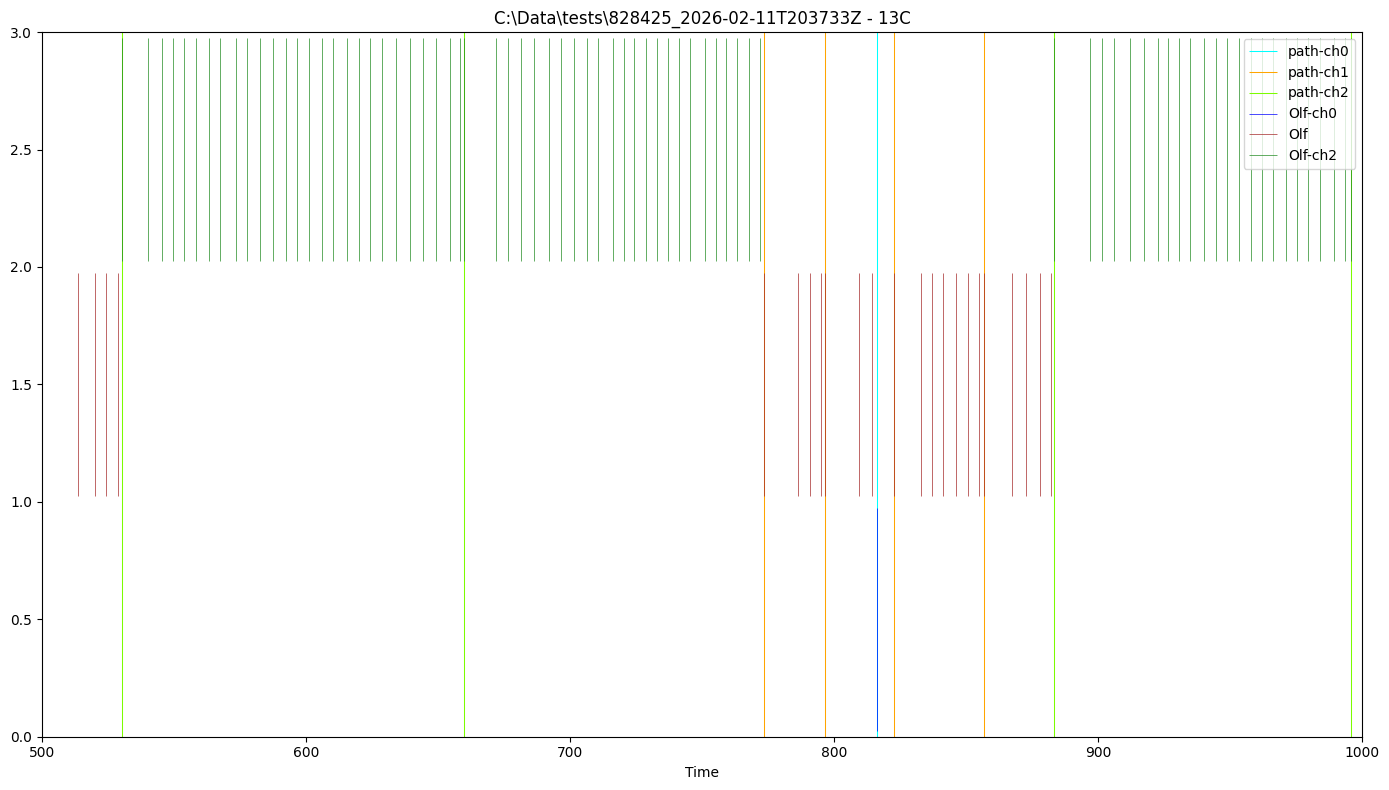

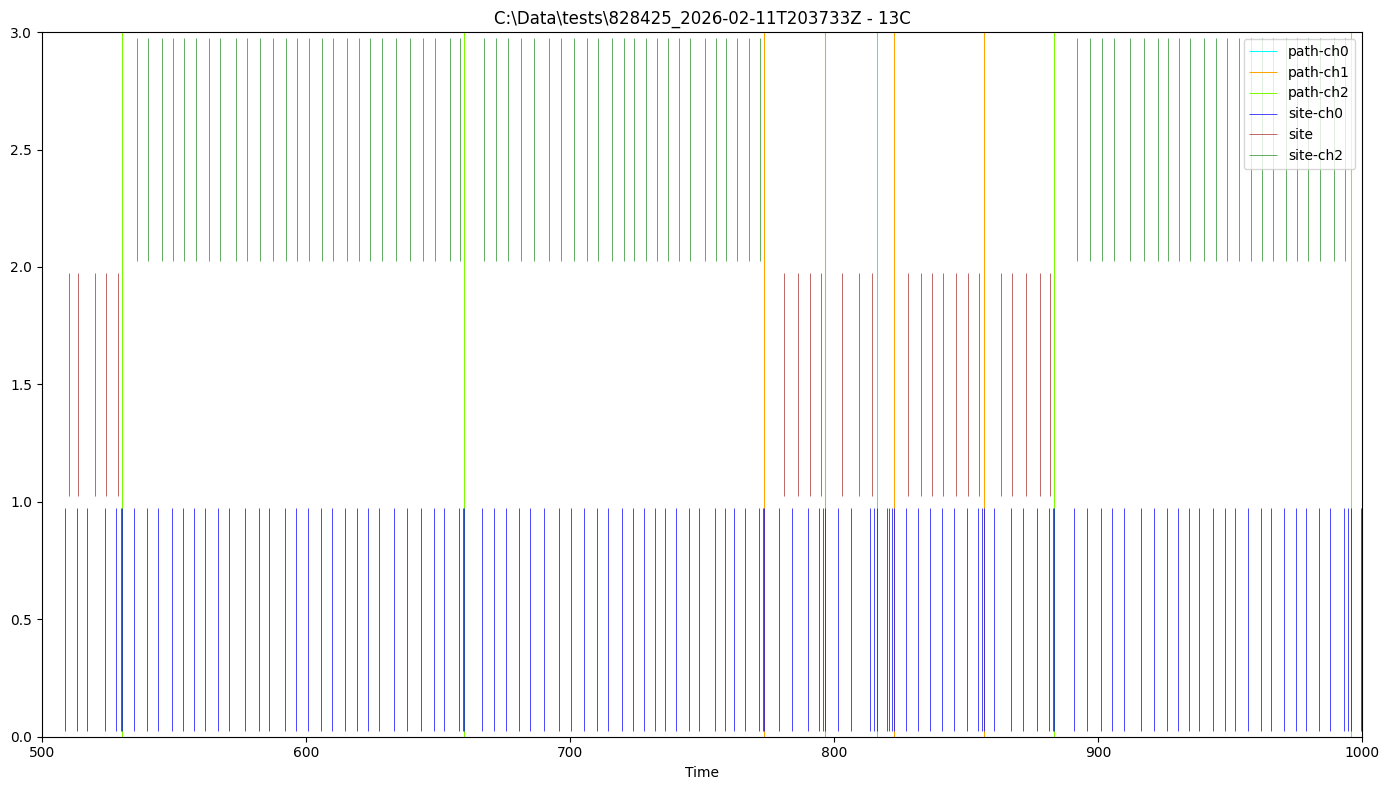

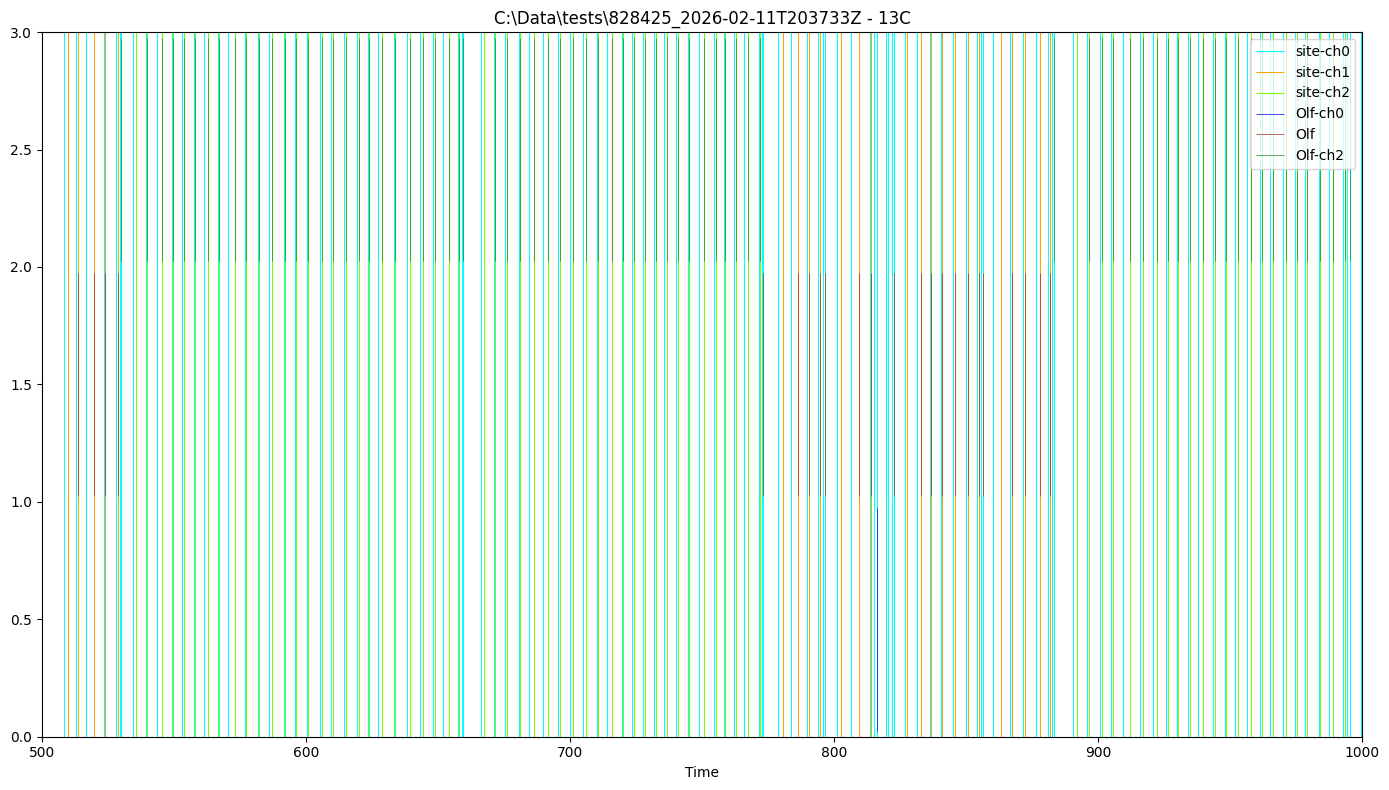

In [26]:
#Single analysis

base_path = r"C:\Data\tests\828425_2026-02-11T203733Z"
rig = get_rig_n(base_path)
run_analysis_in_single_folder(base_path, rig_n=rig, xlim=(500,1000))

Loaded rig info: Computer - ABAIA, Rig - 4D


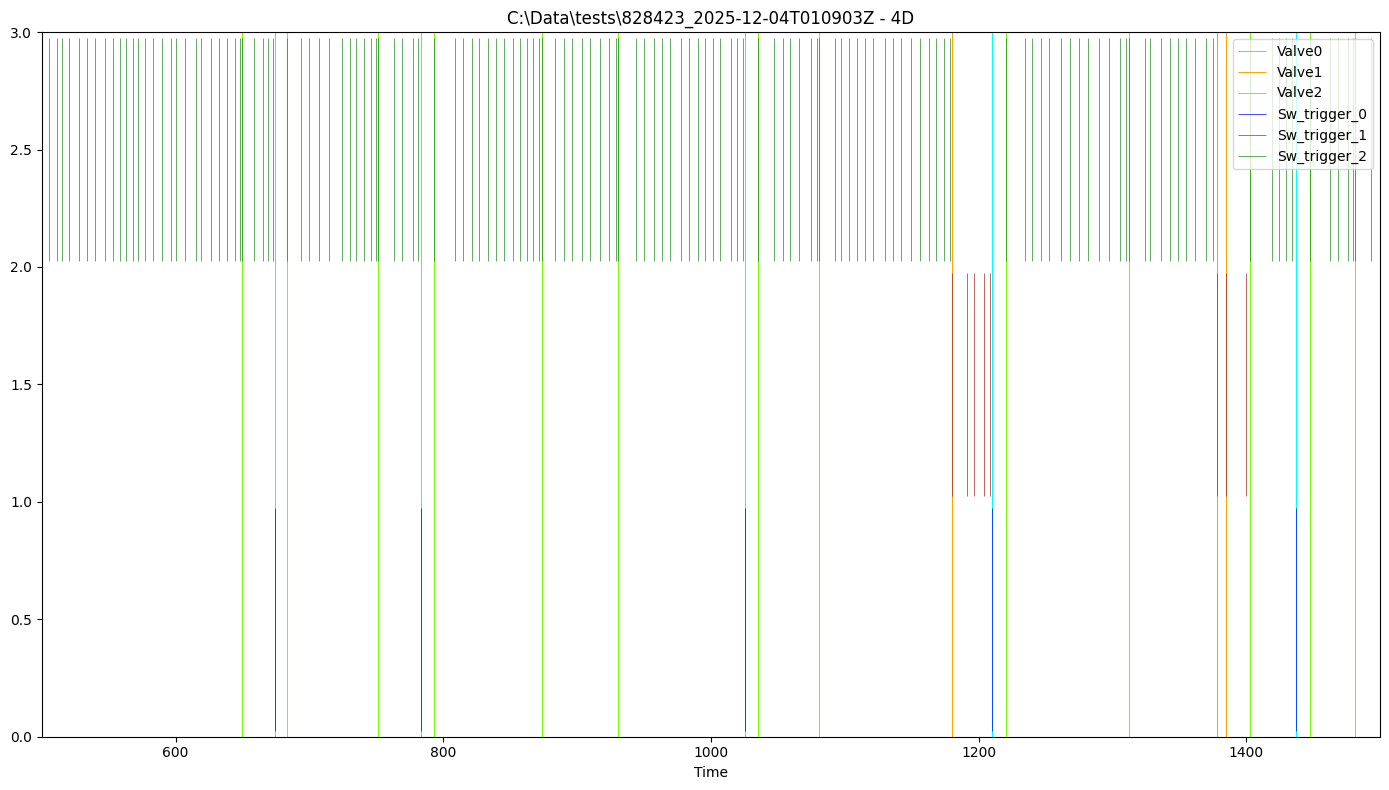

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0          14.0     14.0         1.0    0.016386   0.007739   0.033184
1          37.0     37.0         1.0    0.021419   0.012711   0.063168
2          44.0     44.0         1.0    0.023194   0.016967   0.071168
Loaded rig info: Computer - YACUMAMA, Rig - 4C


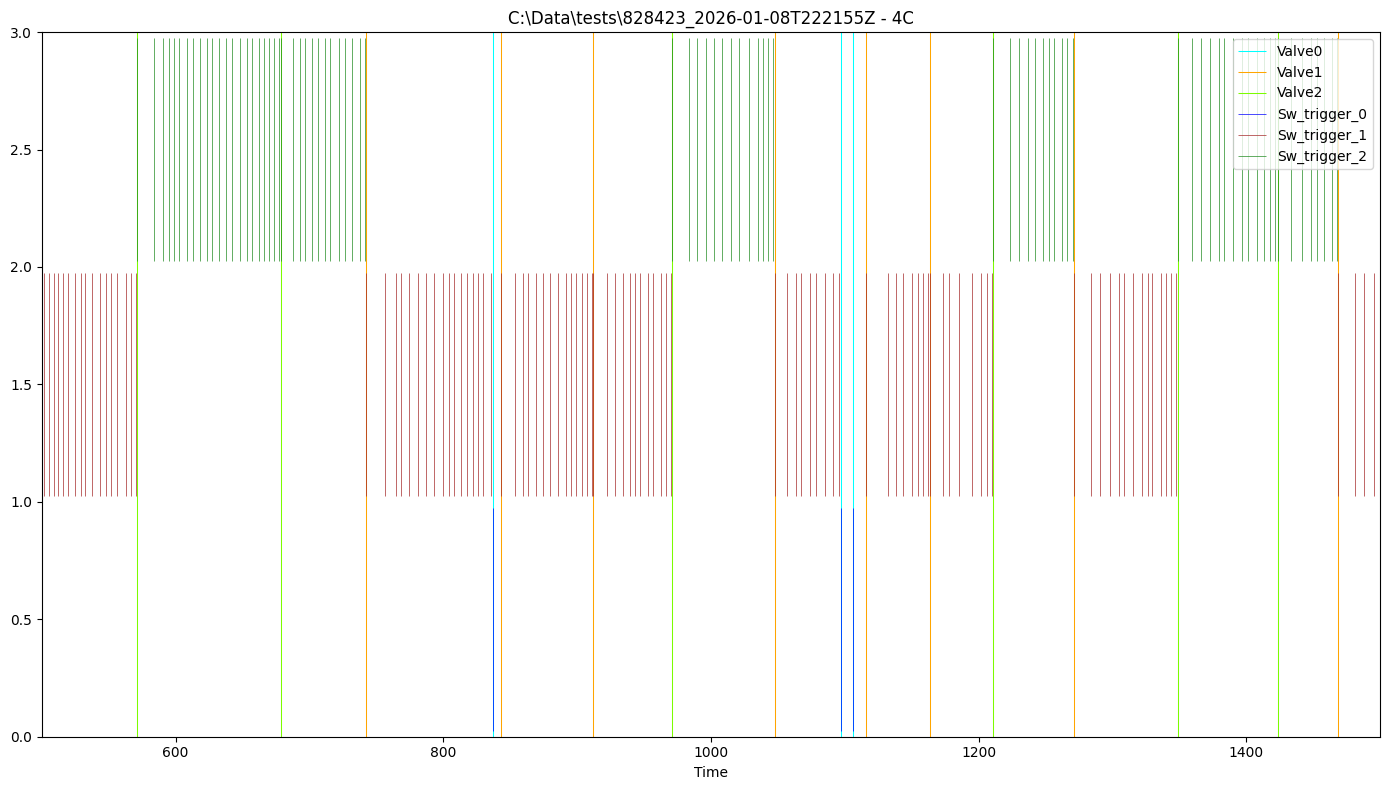

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0           9.0      9.0         1.0    0.017259   0.010423   0.037504
1          40.0     40.0         1.0    0.022684   0.013576   0.064480
2          28.0     28.0         1.0    0.019701   0.010512   0.043488
Loaded rig info: Computer - YACUMAMA, Rig - 4C


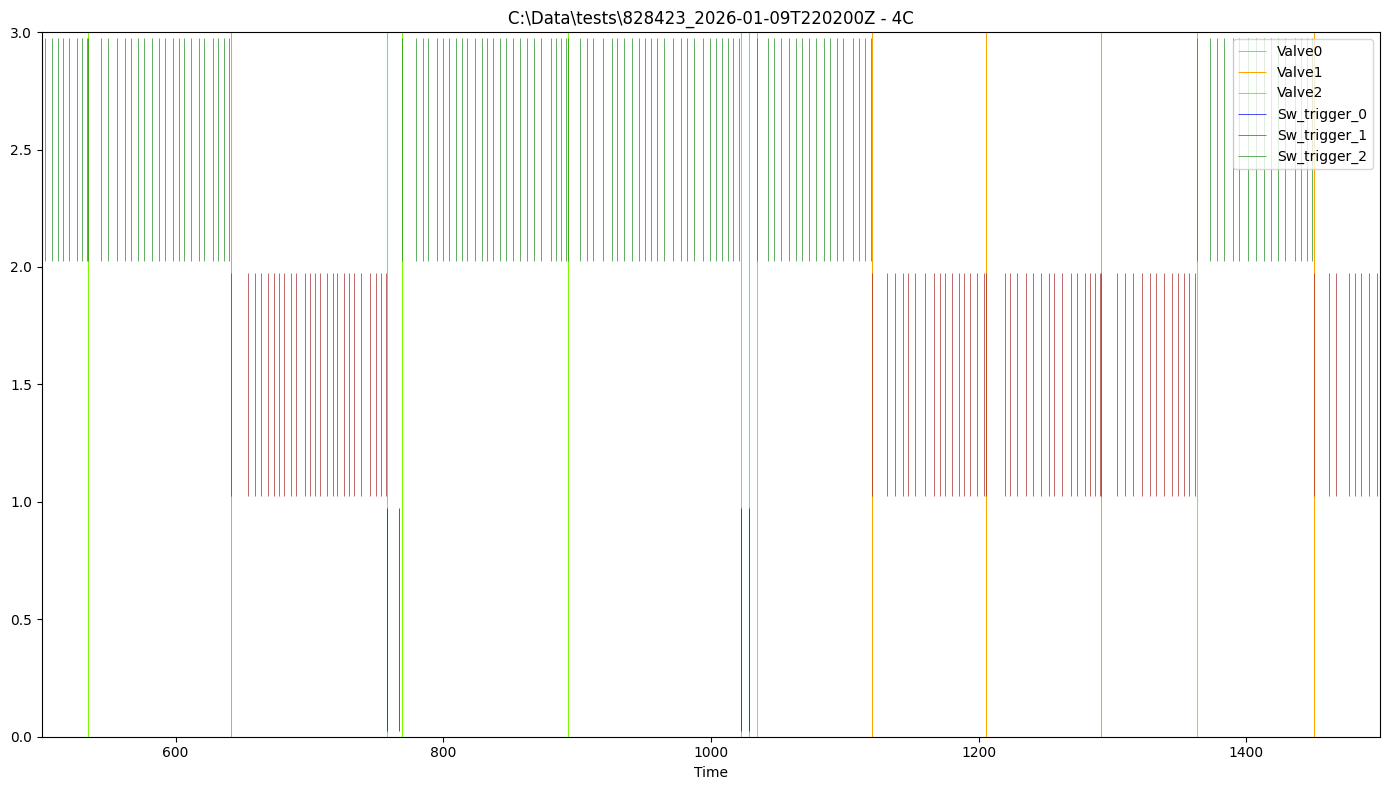

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0           9.0      9.0         1.0    0.024448   0.018447   0.057216
1          34.0     34.0         1.0    0.021231   0.011710   0.058240
2          29.0     29.0         1.0    0.023231   0.013753   0.062240
Loaded rig info: Computer - YACUMAMA, Rig - 4C


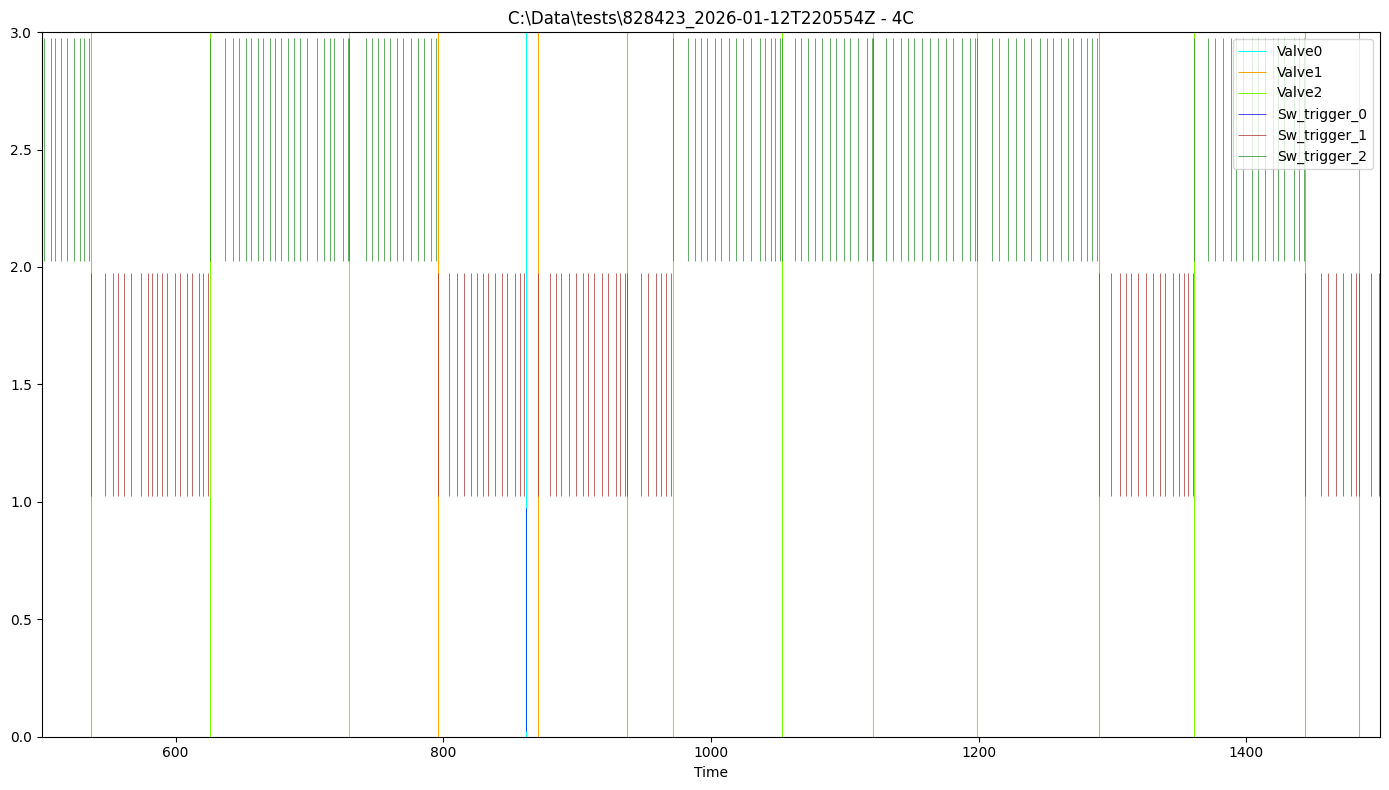

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0           2.0      2.0         1.0    0.016832   0.007784   0.022336
1          38.0     38.0         1.0    0.022765   0.014966   0.073344
2          25.0     25.0         1.0    0.019021   0.012797   0.053344
Loaded rig info: Computer - YACUMAMA, Rig - 4C


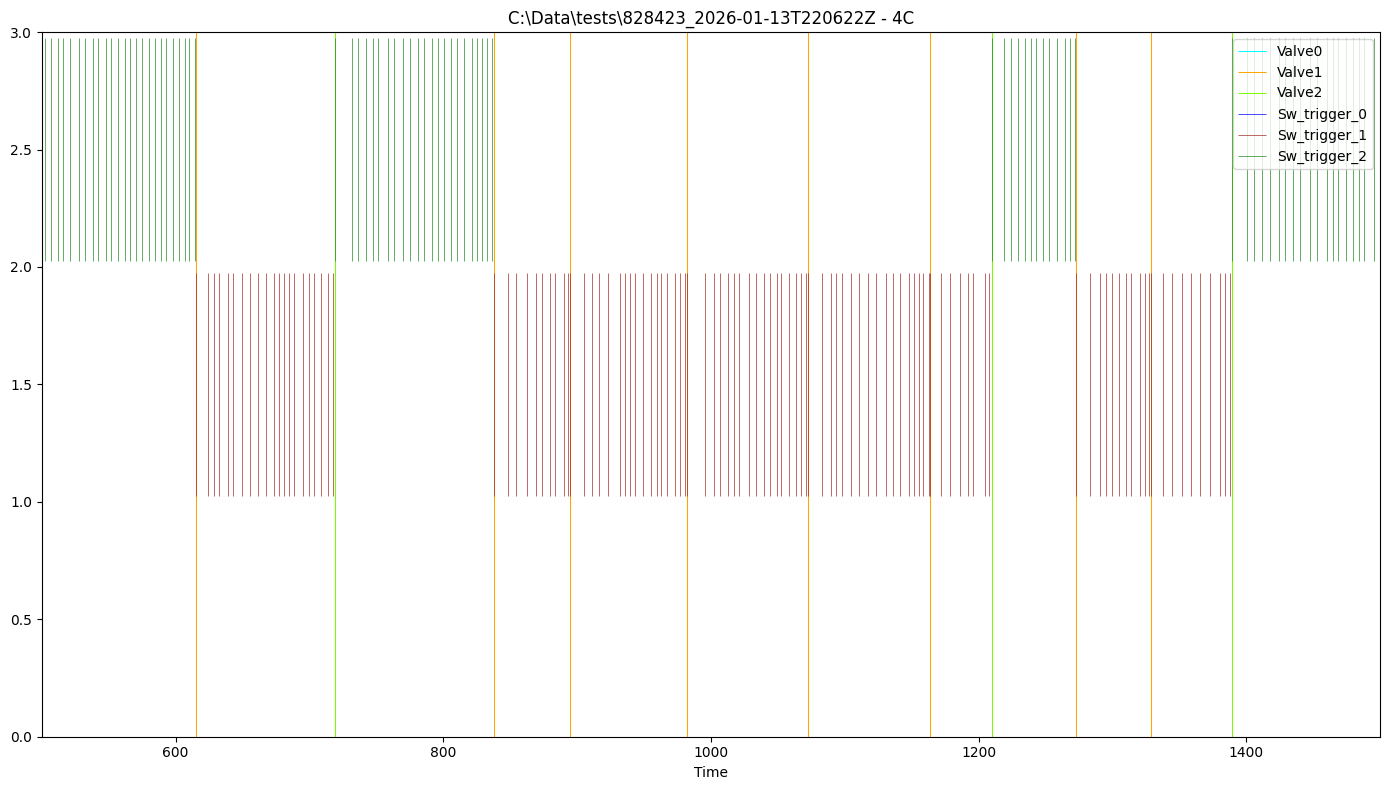

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0           5.0      5.0         1.0    0.016992   0.007597   0.029792
1          26.0     26.0         1.0    0.019524   0.010792   0.054784
2          21.0     21.0         1.0    0.018411   0.010717   0.046784
Loaded rig info: Computer - YACUMAMA, Rig - 4C


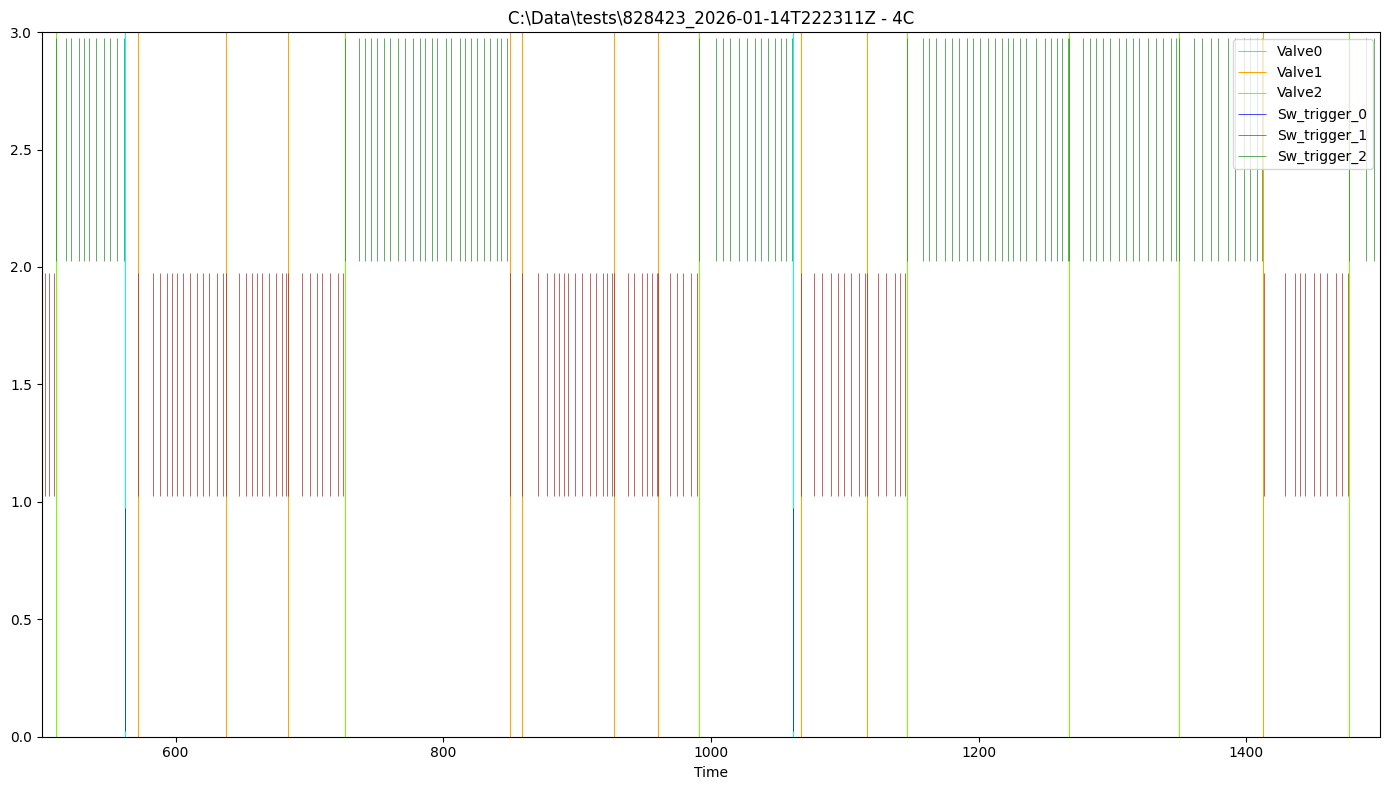

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0          10.0     10.0         1.0    0.020963   0.011387   0.038272
1          38.0     38.0         1.0    0.022189   0.015977   0.074272
2          39.0     39.0         1.0    0.021758   0.013098   0.060288
Loaded rig info: Computer - YACUMAMA, Rig - 4C


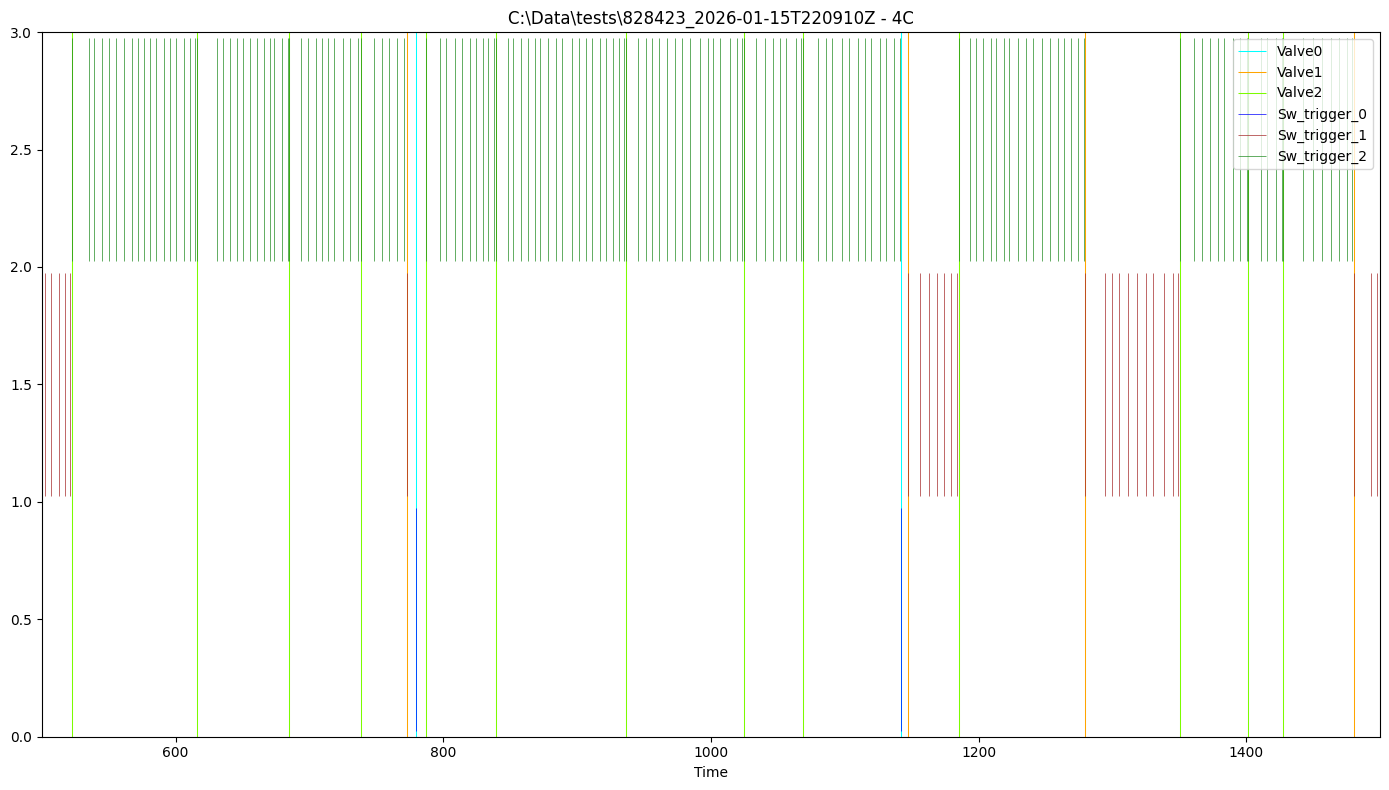

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0          10.0     10.0         1.0    0.017488   0.007855   0.034688
1          34.0     34.0         1.0    0.023308   0.012588   0.061696
2          42.0     42.0         1.0    0.021715   0.012064   0.059712
Loaded rig info: Computer - YACUMAMA, Rig - 4C


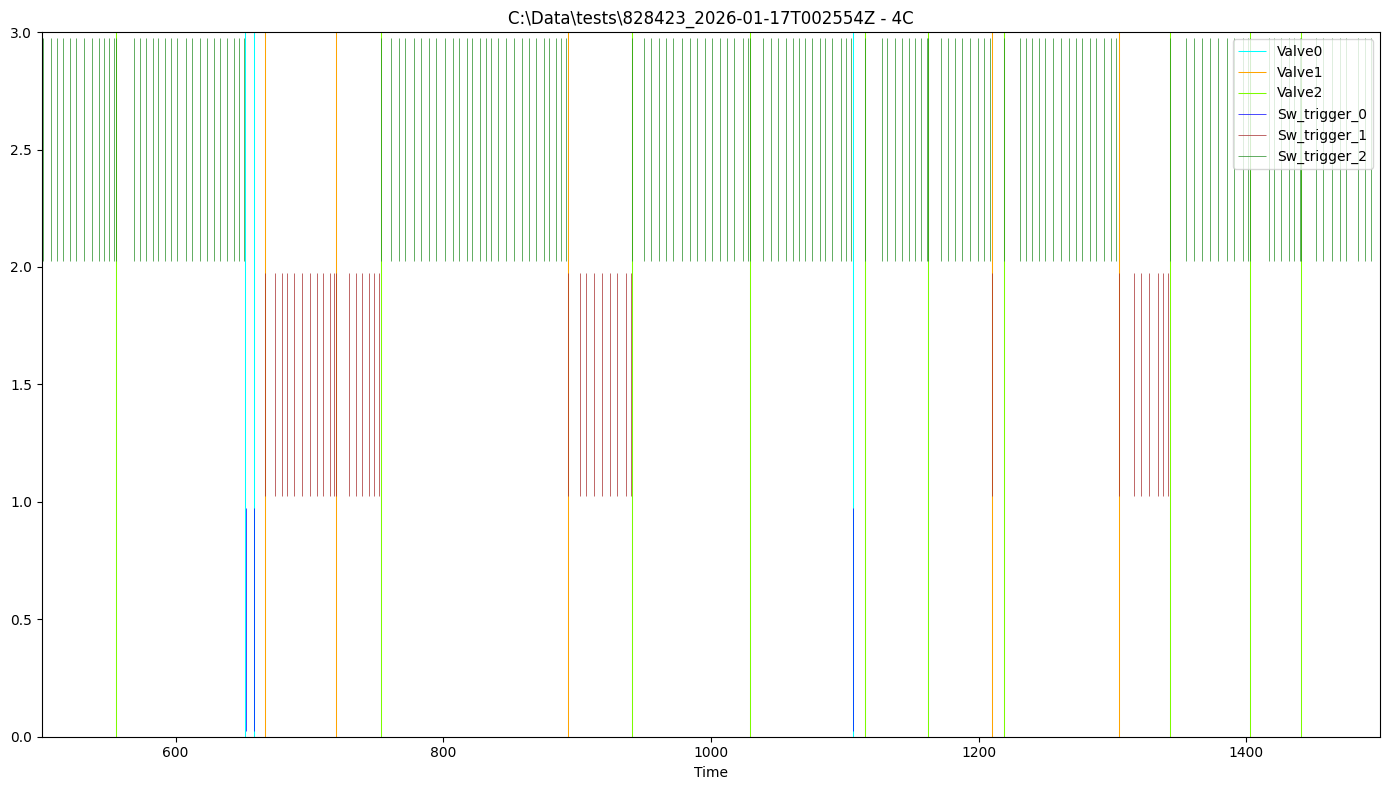

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0           7.0      7.0         1.0    0.021138   0.011706   0.040000
1          18.0     18.0         1.0    0.018713   0.009117   0.038976
2          22.0     22.0         1.0    0.023948   0.015492   0.068992
Loaded rig info: Computer - YACUMAMA, Rig - 4C


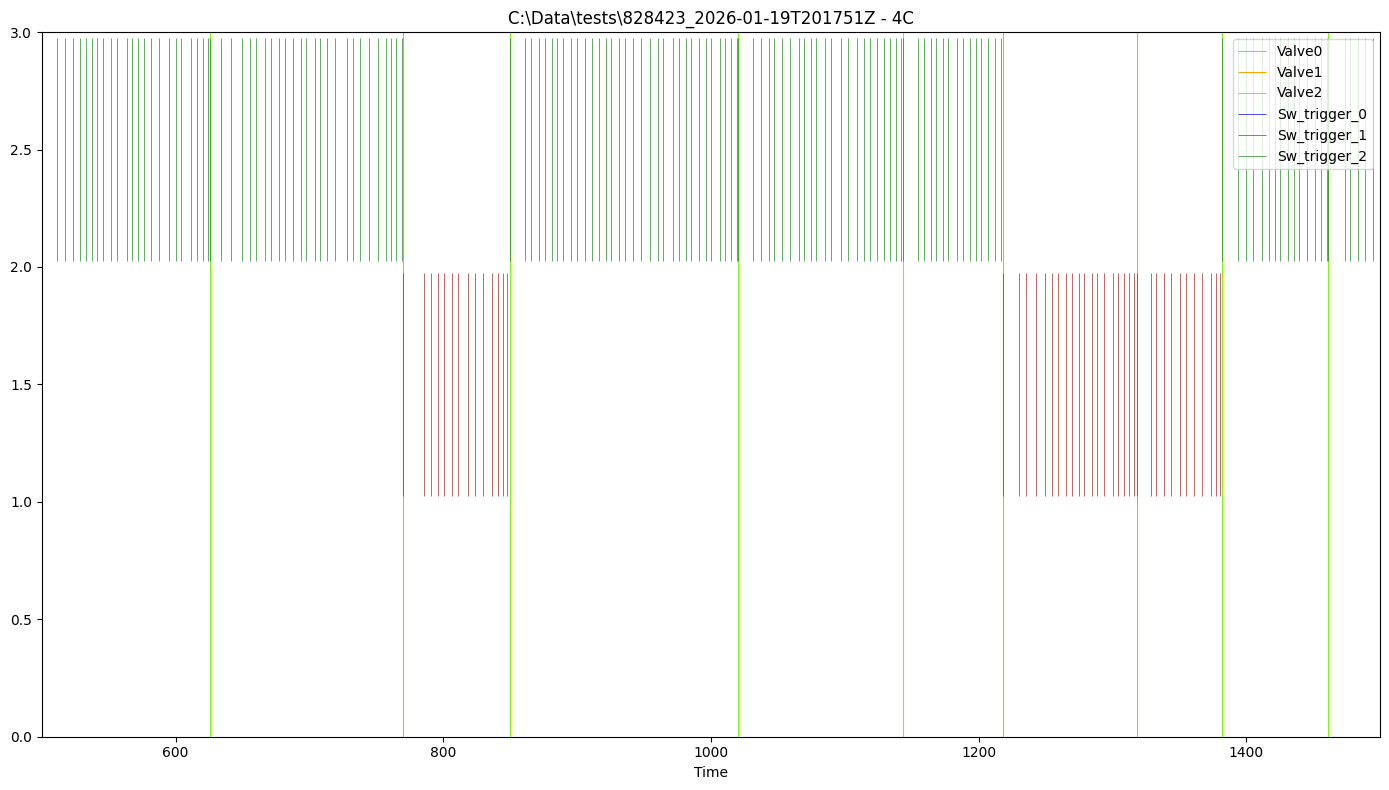

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0           2.0      2.0         1.0    0.017840   0.006358   0.022336
1          21.0     21.0         1.0    0.016803   0.008934   0.041344
2          20.0     20.0         1.0    0.019285   0.010251   0.047360
Loaded rig info: Computer - DT714698, Rig - Ephys5


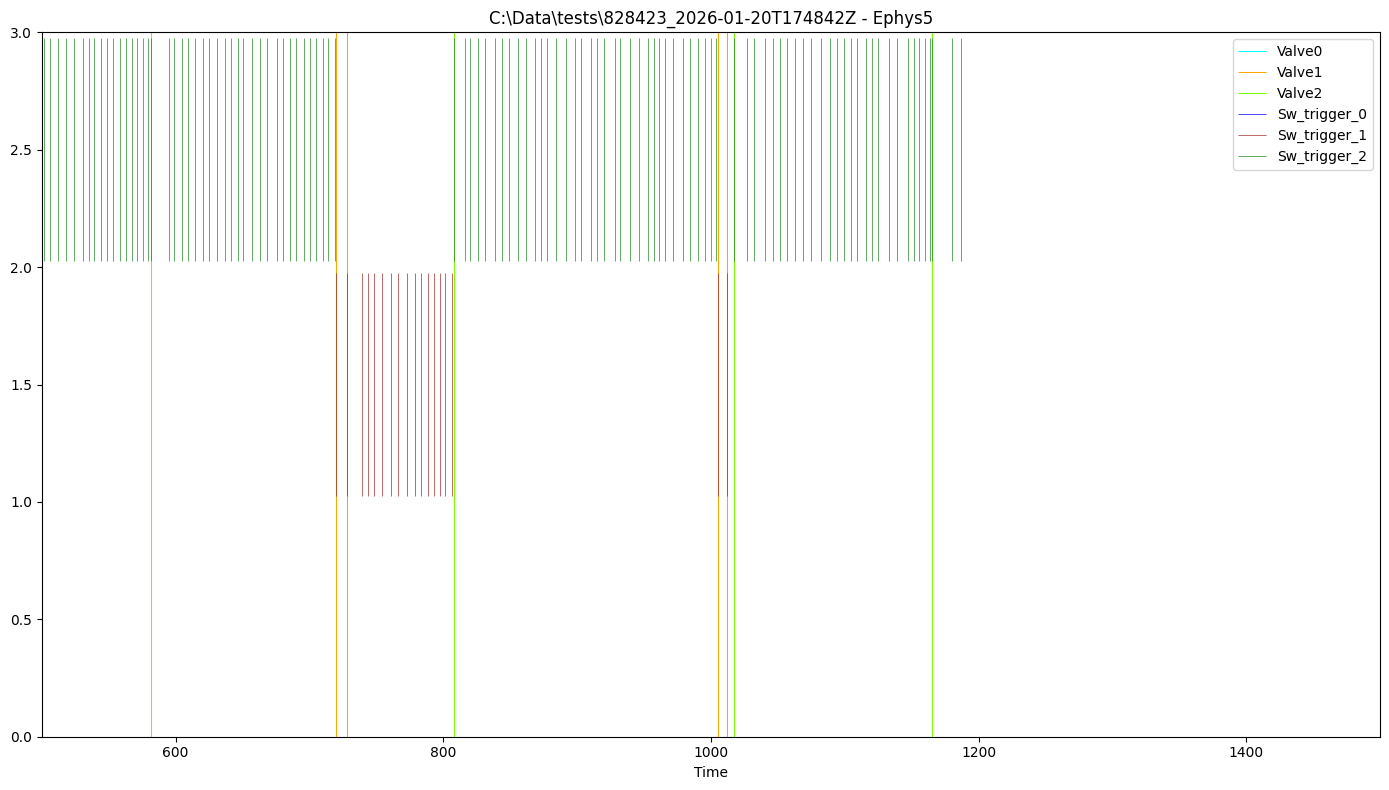

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0           1.0      1.0         1.0    0.037696   0.000000   0.037696
1           4.0      4.0         1.0    0.025720   0.011639   0.041728
2           6.0      6.0         1.0    0.033227   0.008979   0.050720
Loaded rig info: Computer - DT300185, Rig - 13D


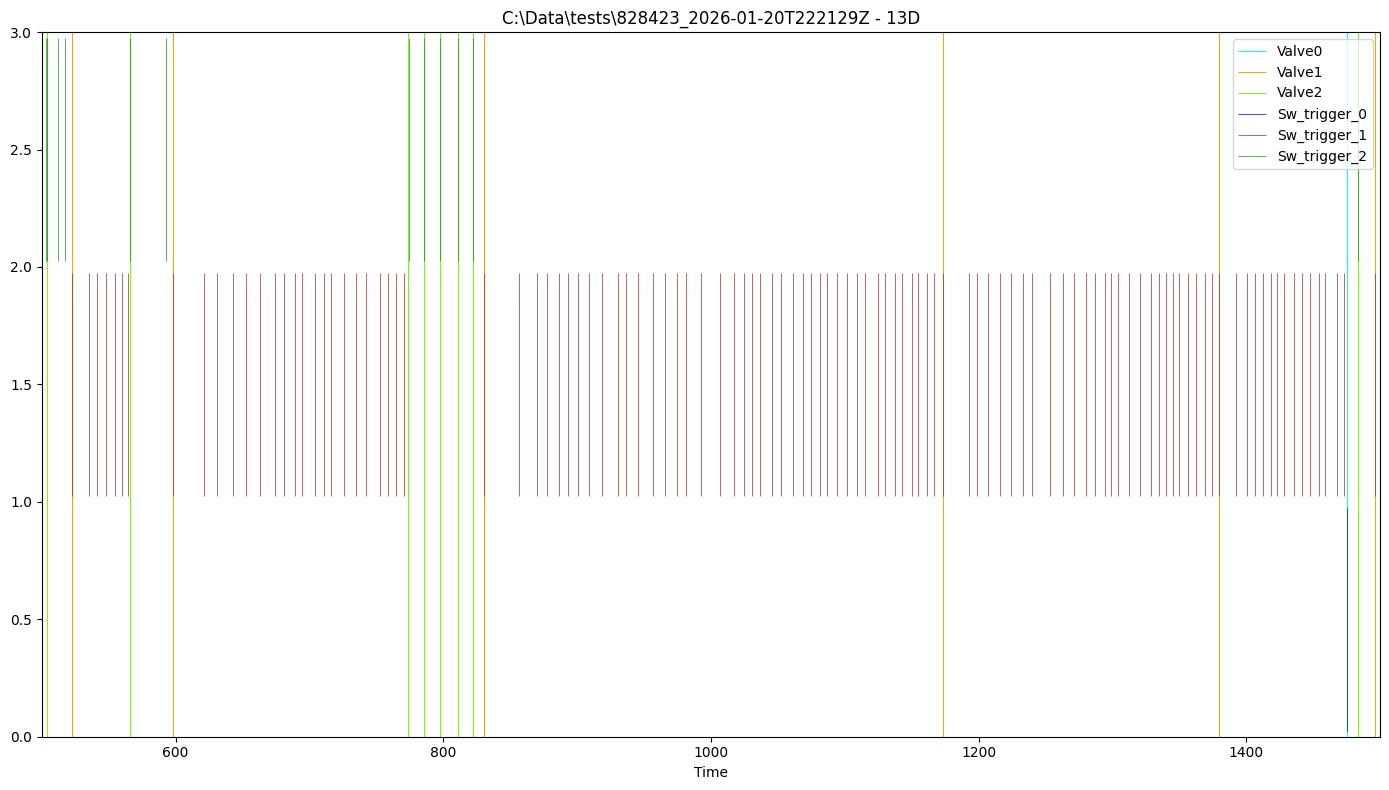

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0          17.0     17.0         1.0    0.021480   0.015396   0.060960
1          46.0     46.0         1.0    0.023840   0.014273   0.076928
2          51.0     51.0         1.0    0.021476   0.012777   0.067936
Loaded rig info: Computer - DT300185, Rig - 13D


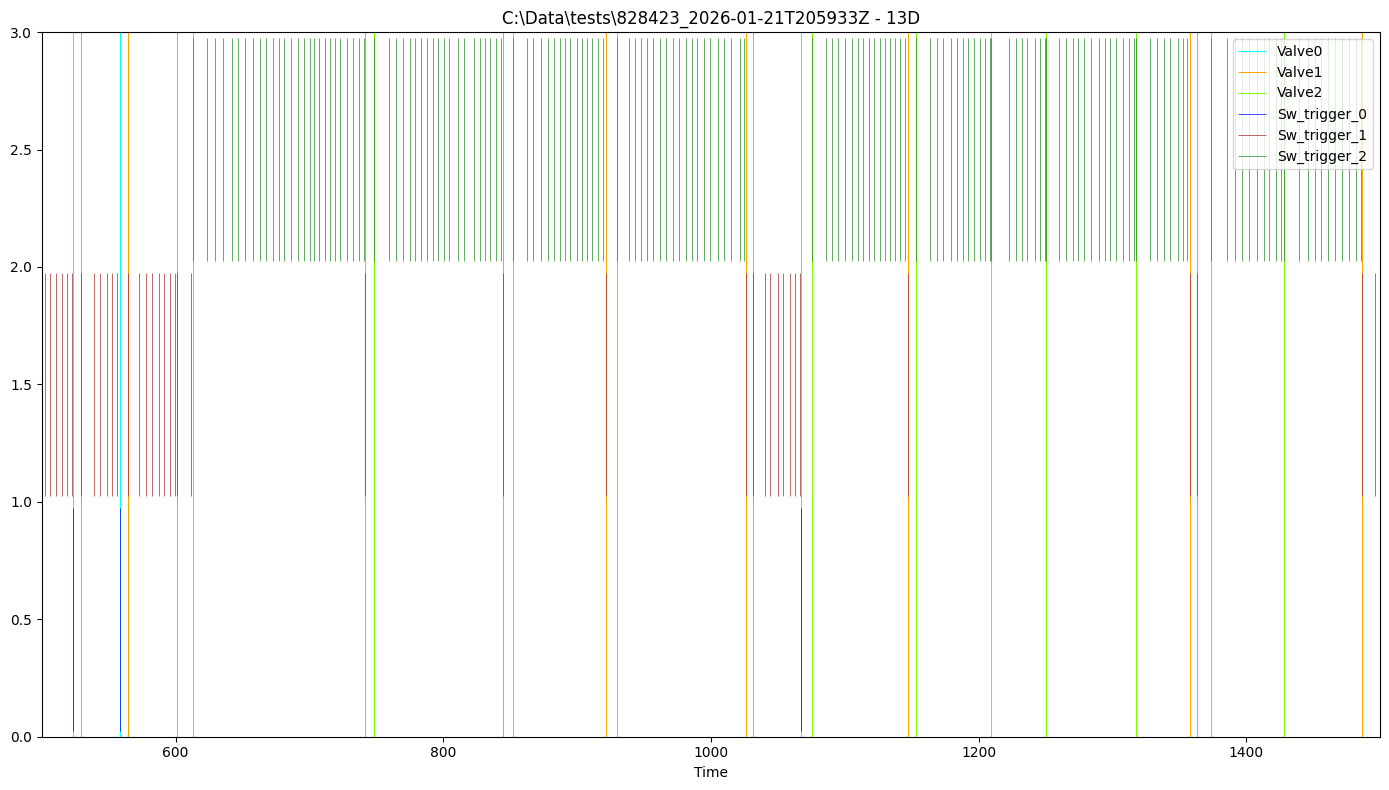

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0          14.0     14.0         1.0    0.023003   0.012216   0.053376
1          52.0     52.0         1.0    0.021263   0.012522   0.077376
2          51.0     51.0         1.0    0.019245   0.011145   0.065376
Loaded rig info: Computer - DT300043, Rig - 13B


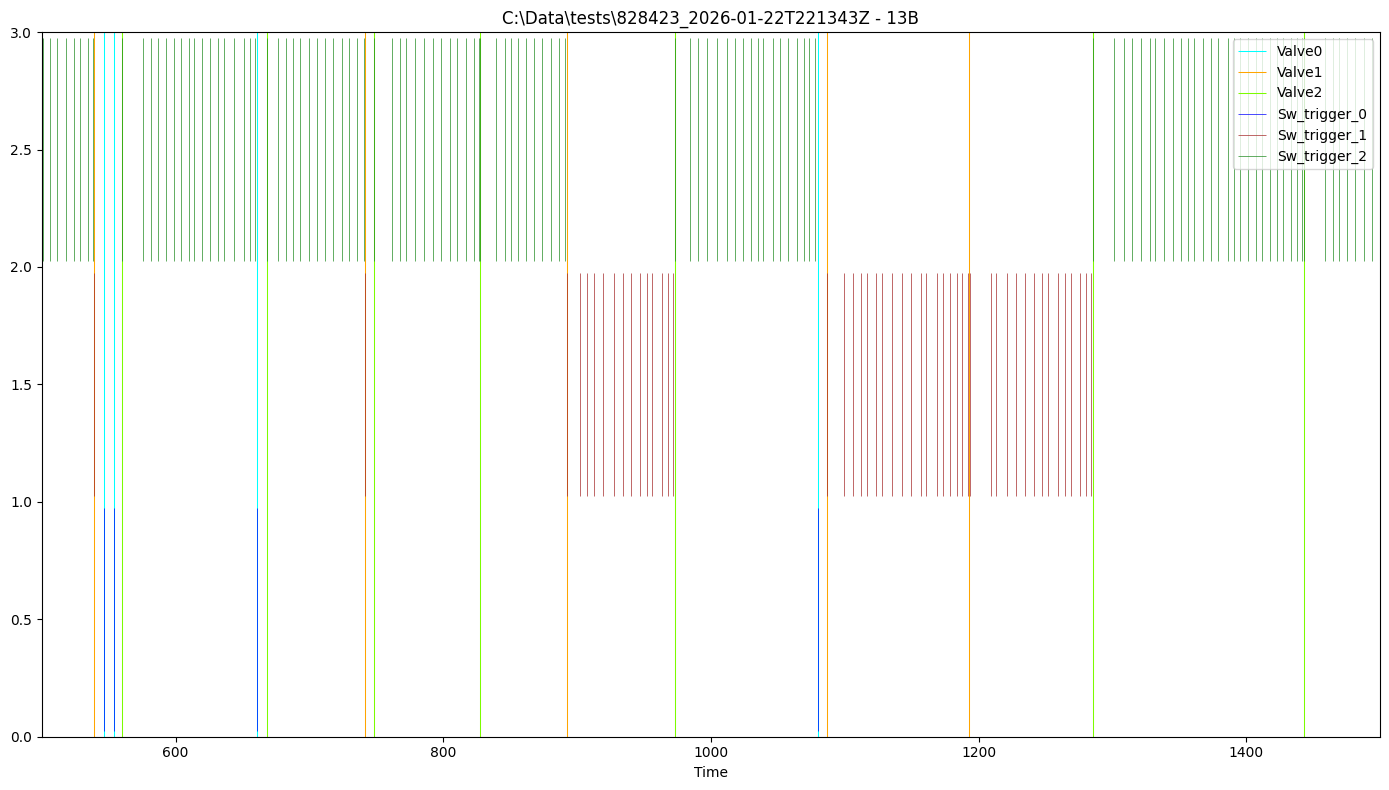

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0          11.0     11.0     1.00000    0.020567   0.011144   0.043936
1          42.0     41.0     0.97619    0.022276   0.017531   0.102944
2          50.0     50.0     1.00000    0.022385   0.012873   0.062944
Loaded rig info: Computer - DT700150, Rig - 13C


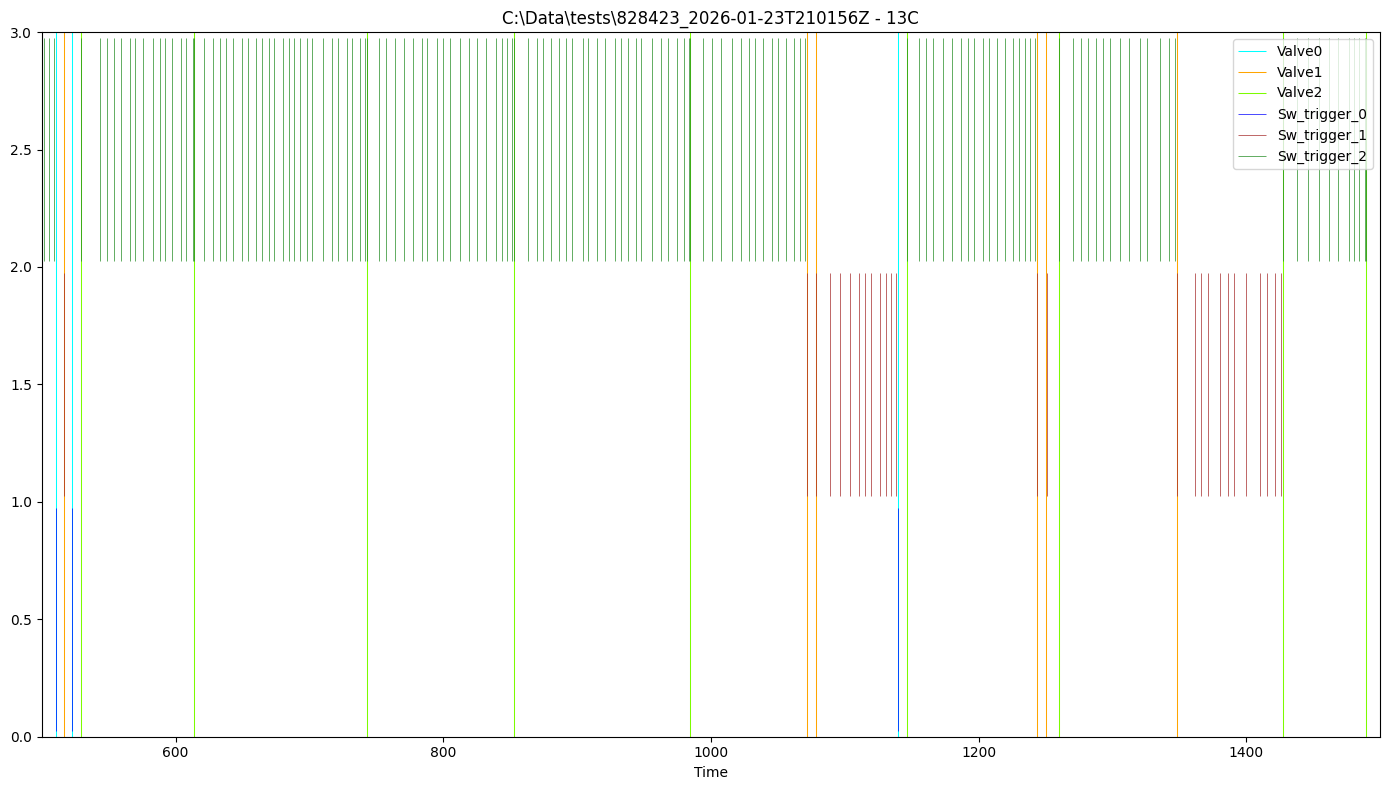

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0          20.0     20.0         1.0    0.018648   0.014447   0.064416
1          40.0     40.0         1.0    0.022421   0.014572   0.057408
2          31.0     31.0         1.0    0.017398   0.011369   0.052384
Loaded rig info: Computer - DT300043, Rig - 13B


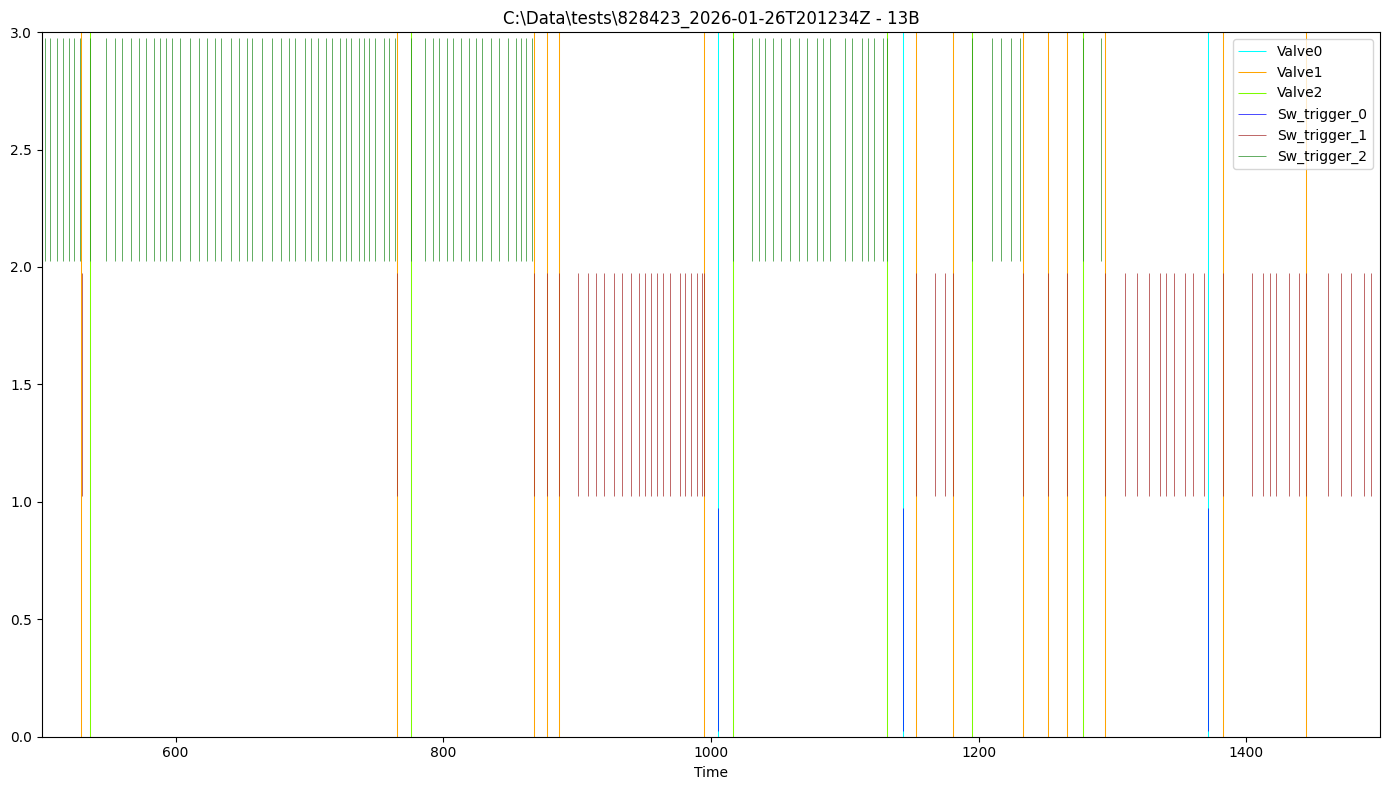

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0          15.0     15.0         1.0    0.019260   0.010931    0.04784
1          65.0     65.0         1.0    0.017799   0.012175    0.06688
2          48.0     48.0         1.0    0.026961   0.017648    0.06784
Loaded rig info: Computer - DT700150, Rig - 13C


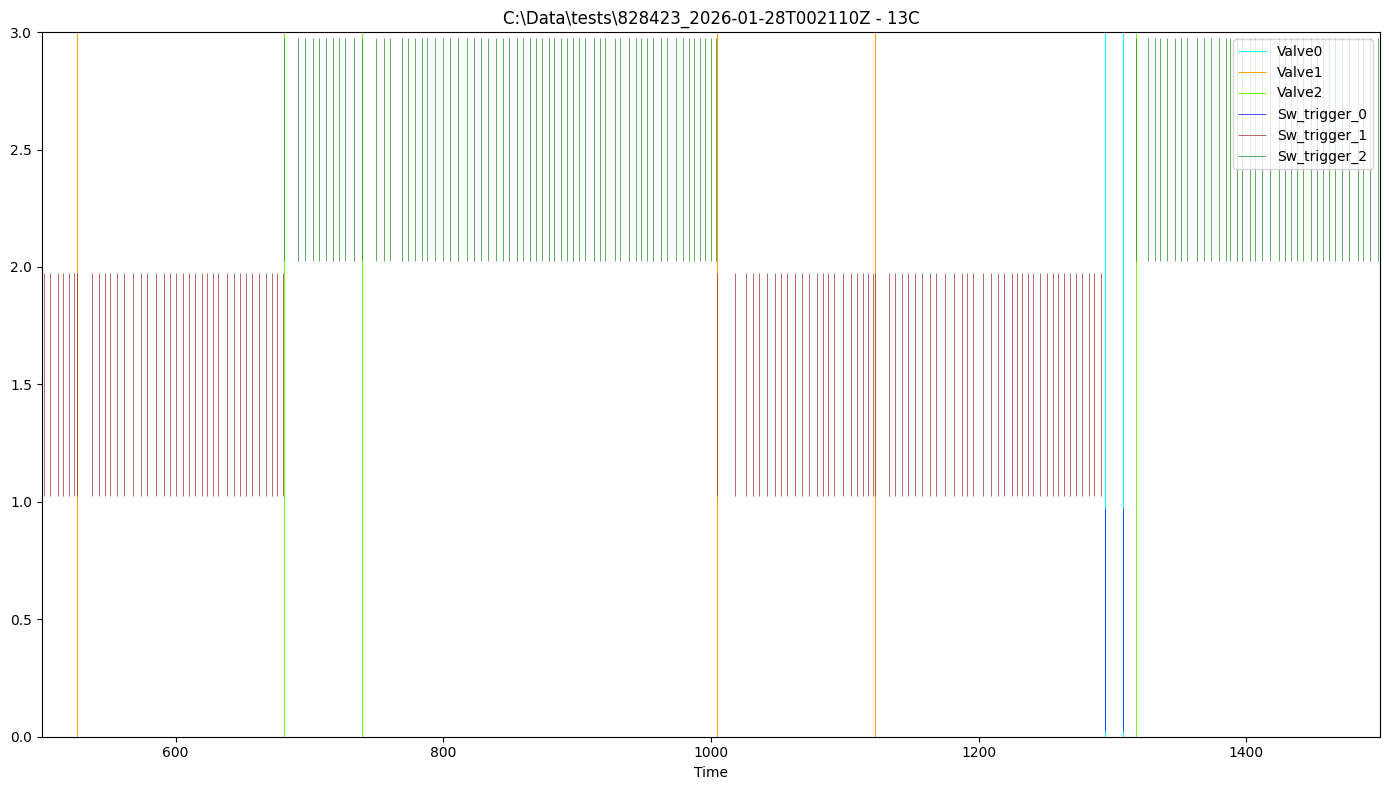

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0           2.0      2.0         1.0    0.028448   0.024754   0.045952
1          15.0     15.0         1.0    0.022479   0.011677   0.040960
2           7.0      7.0         1.0    0.018080   0.005381   0.024928
Loaded rig info: Computer - DT300043, Rig - 13A


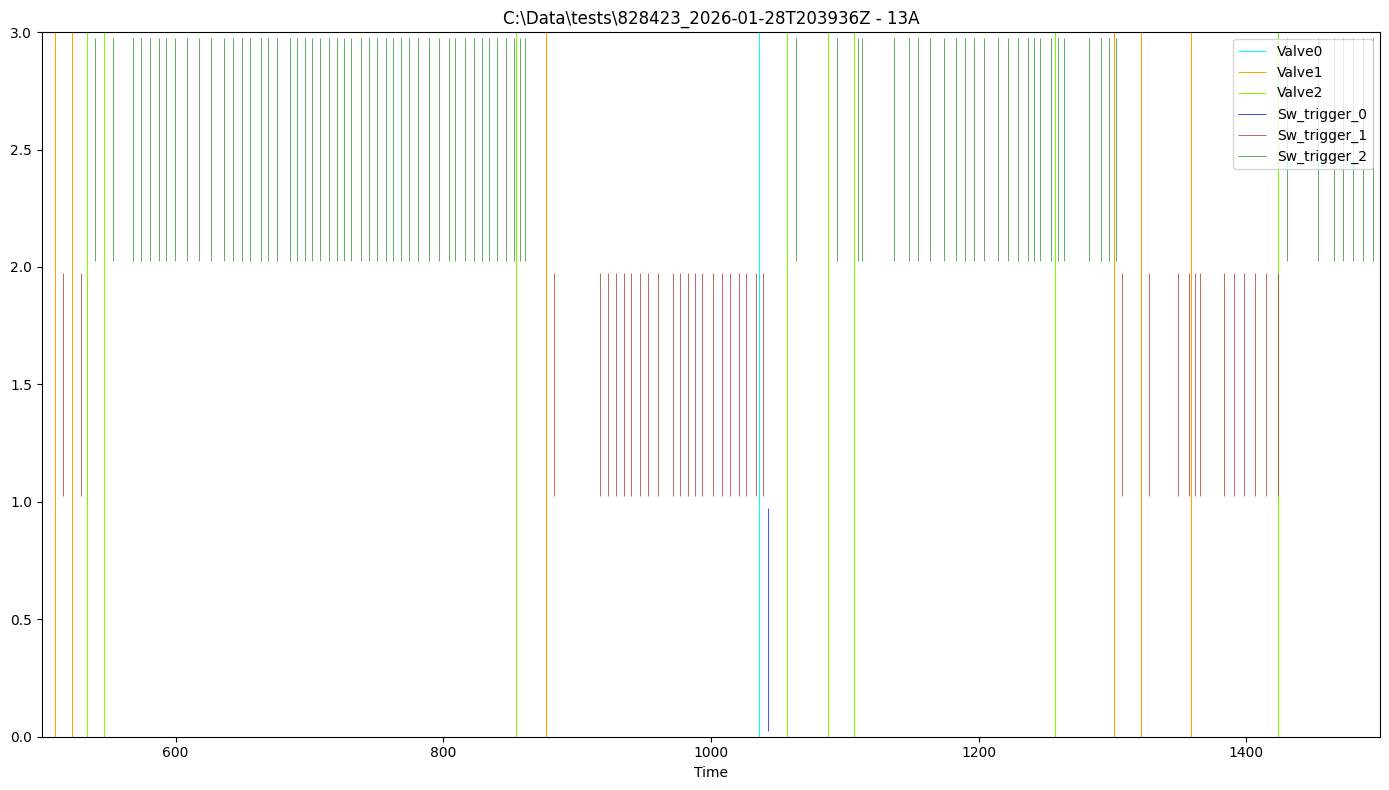

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0          10.0      0.0         0.0    5.999107   1.030363   6.343104
1          35.0      0.0         0.0    6.198650   0.763542   6.360096
2          41.0      0.0         0.0    4.842885   2.118736   6.367104
Loaded rig info: Computer - DT300043, Rig - 13A


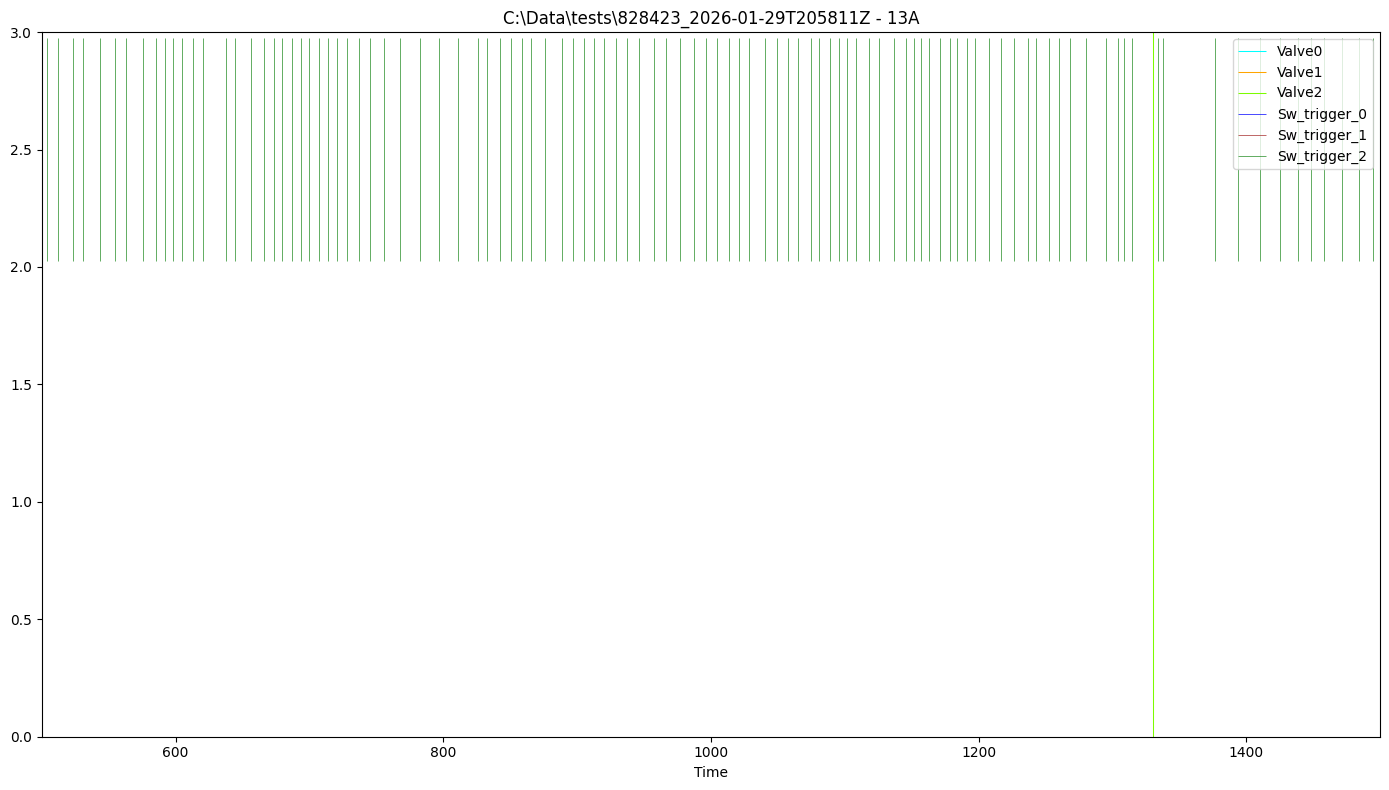

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0           3.0      0.0         0.0    7.069781   0.018498   7.088448
1           8.0      0.0         0.0    6.225212   2.349244   7.097472
2           9.0      0.0         0.0    5.297230   2.718914   7.114432
Loaded rig info: Computer - DT700150, Rig - 13C


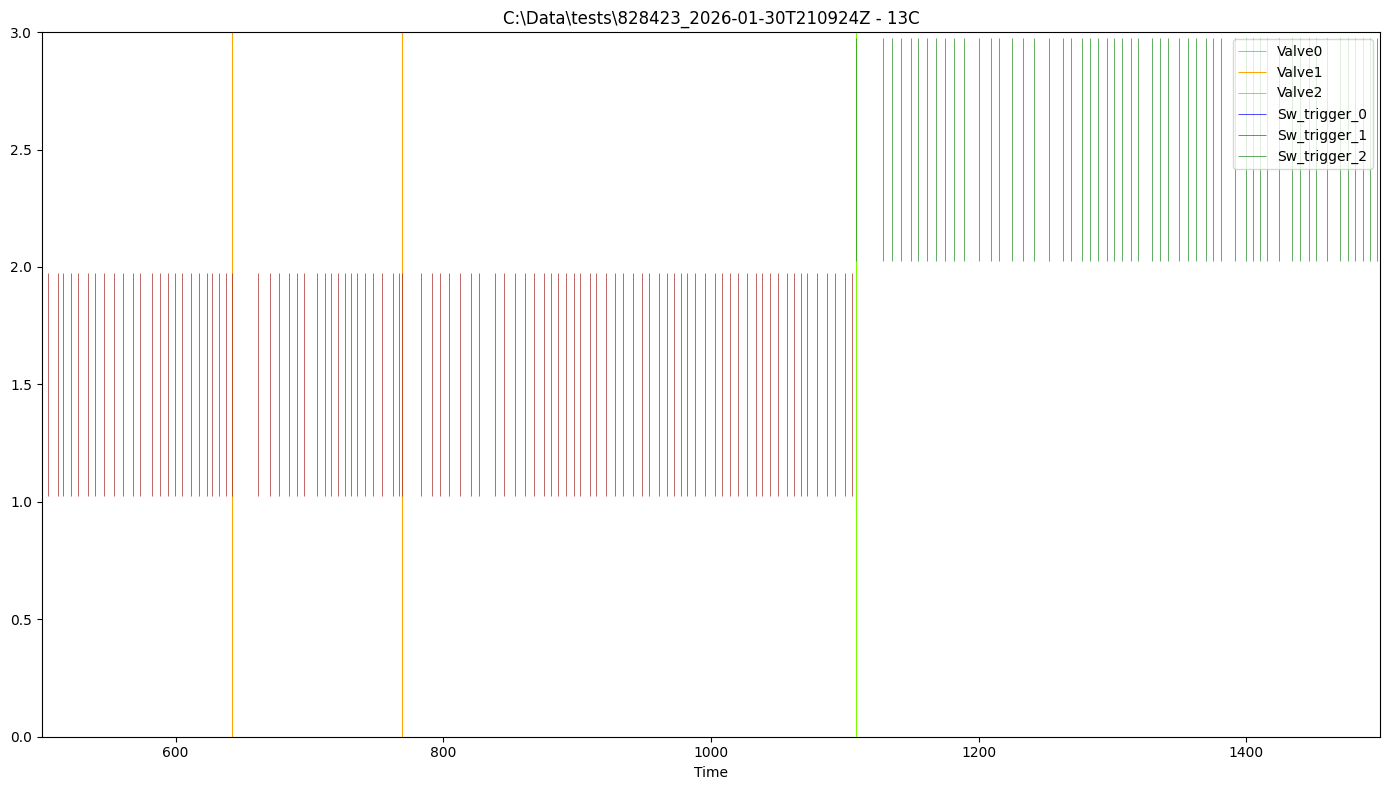

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0           1.0      1.0         1.0    0.010080   0.000000   0.010080
1          10.0     10.0         1.0    0.016387   0.010485   0.036064
2           7.0      7.0         1.0    0.020078   0.009865   0.034080
Loaded rig info: Computer - DT300562, Rig - 13B


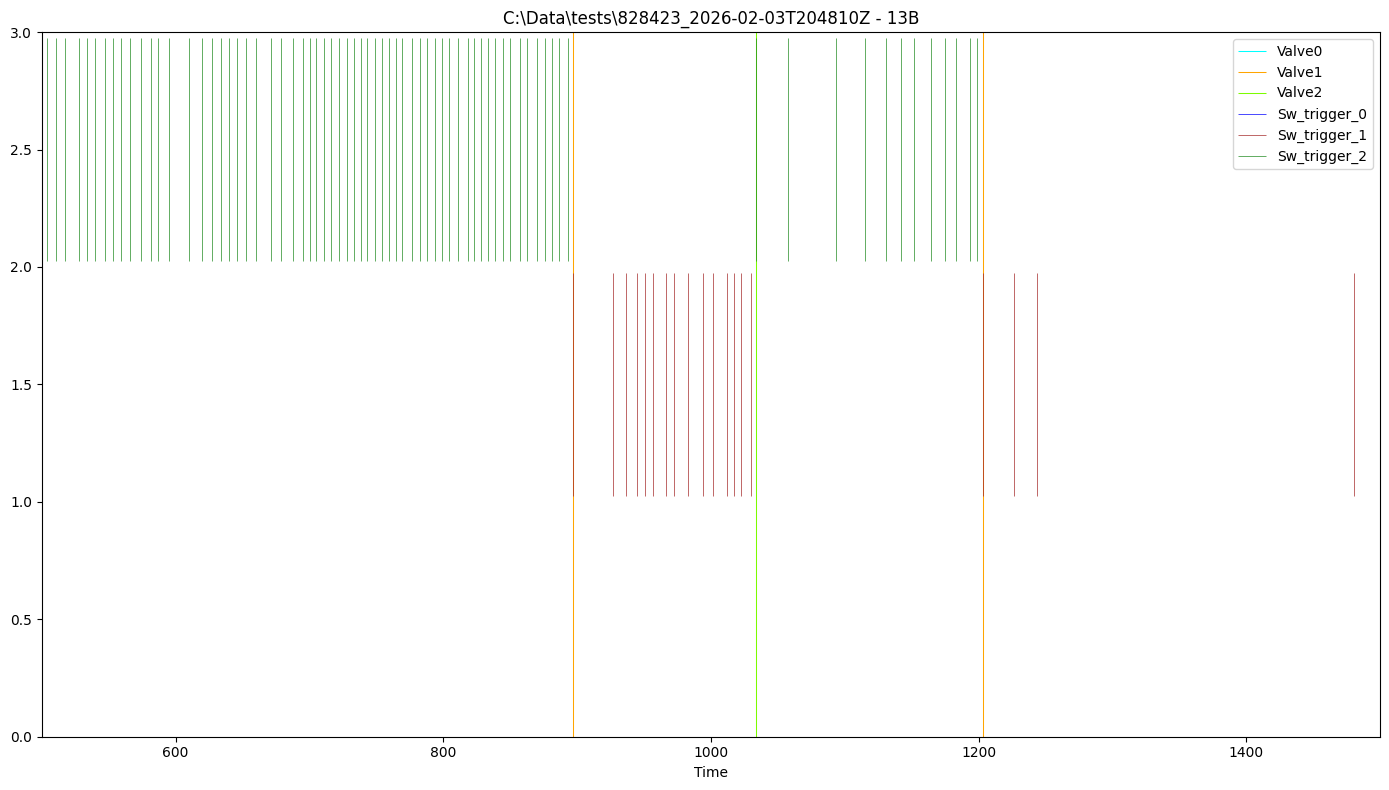

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
1           2.0      2.0         1.0    0.034352   0.017672   0.046848
2           1.0      1.0         1.0    0.024864   0.000000   0.024864
Loaded rig info: Computer - DT300577, Rig - 12A


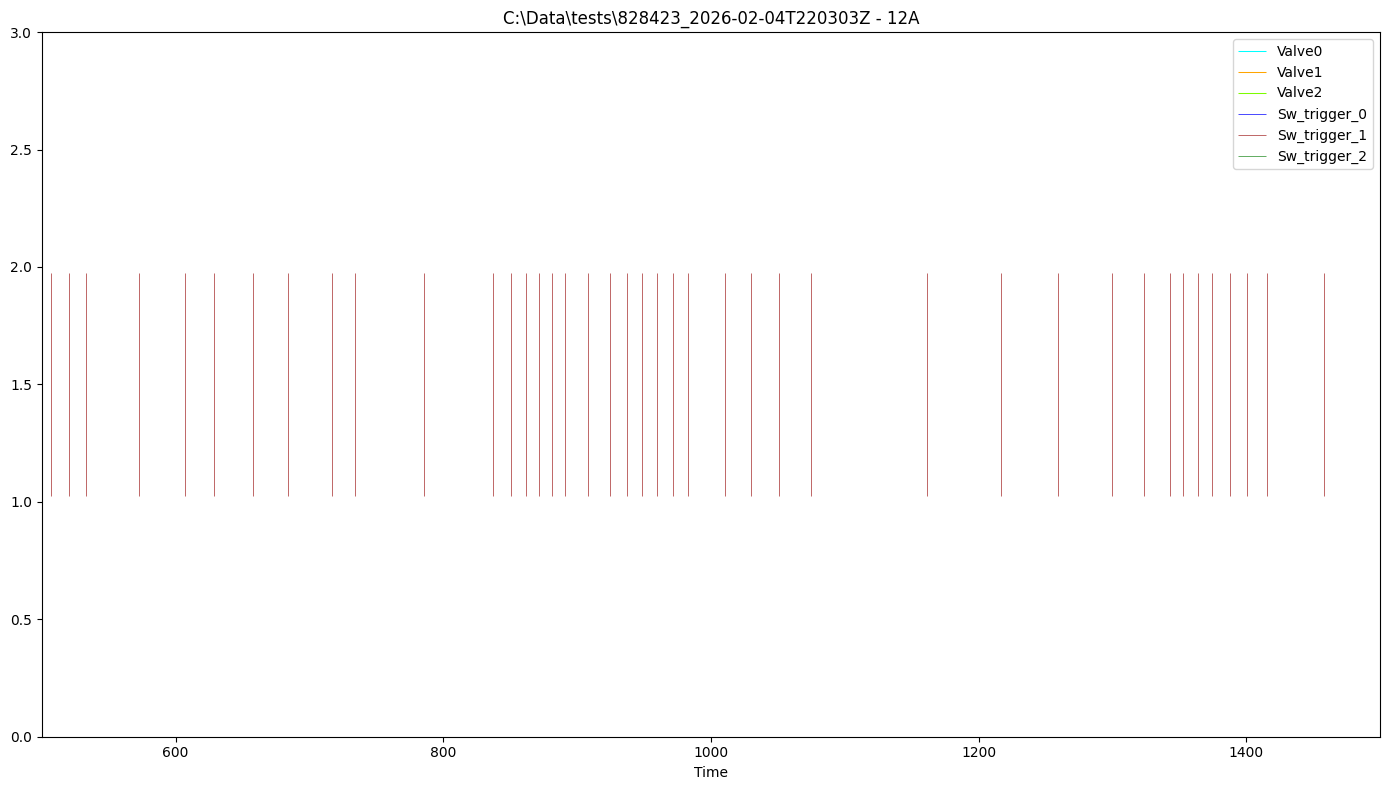

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
2           1.0      1.0         1.0    0.037344        0.0   0.037344
Loaded rig info: Computer - ABAIA, Rig - 4D


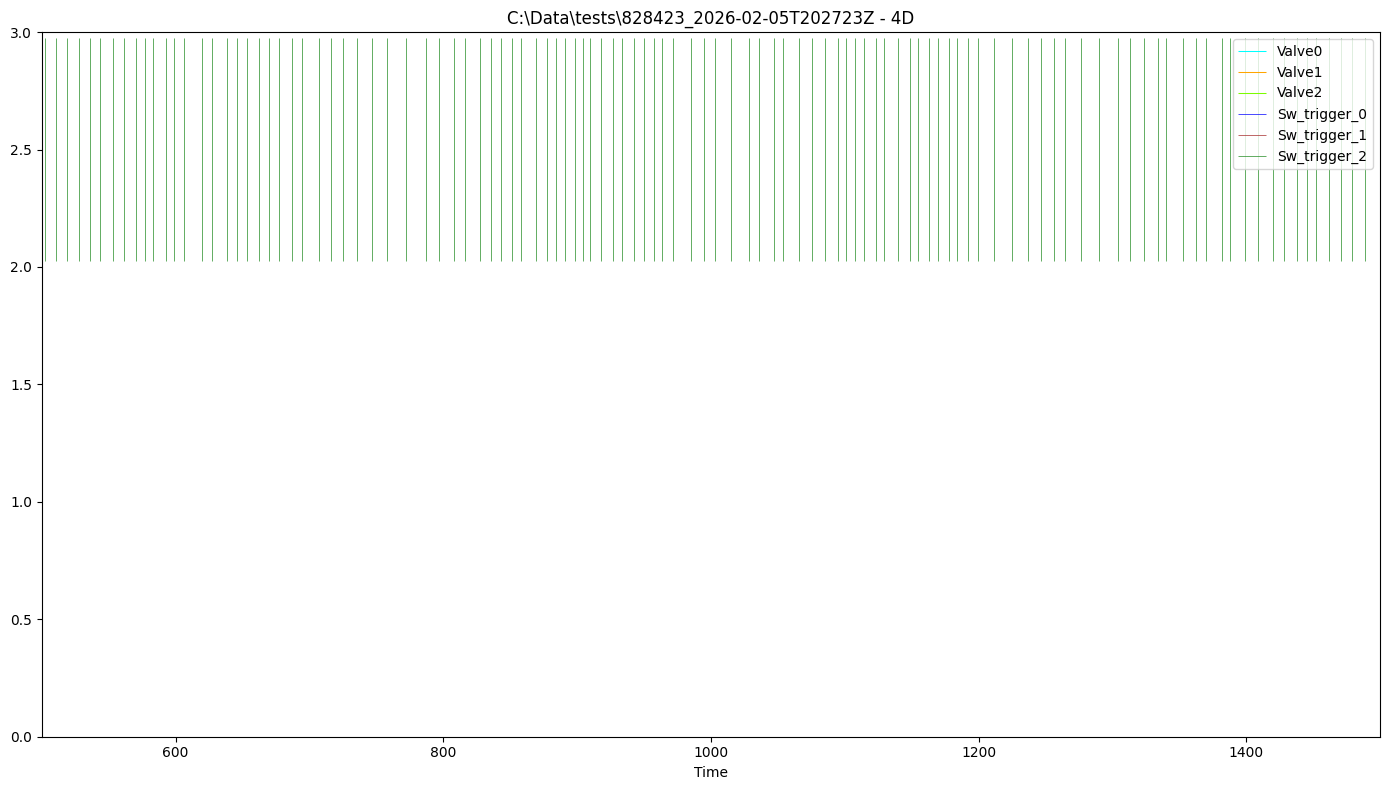

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0           2.0      2.0         1.0    0.020976   0.014142   0.030976
1          10.0     10.0         1.0    0.022659   0.010884   0.039936
2          11.0     11.0         1.0    0.026694   0.016209   0.060960
Loaded rig info: Computer - DT700150, Rig - 13C


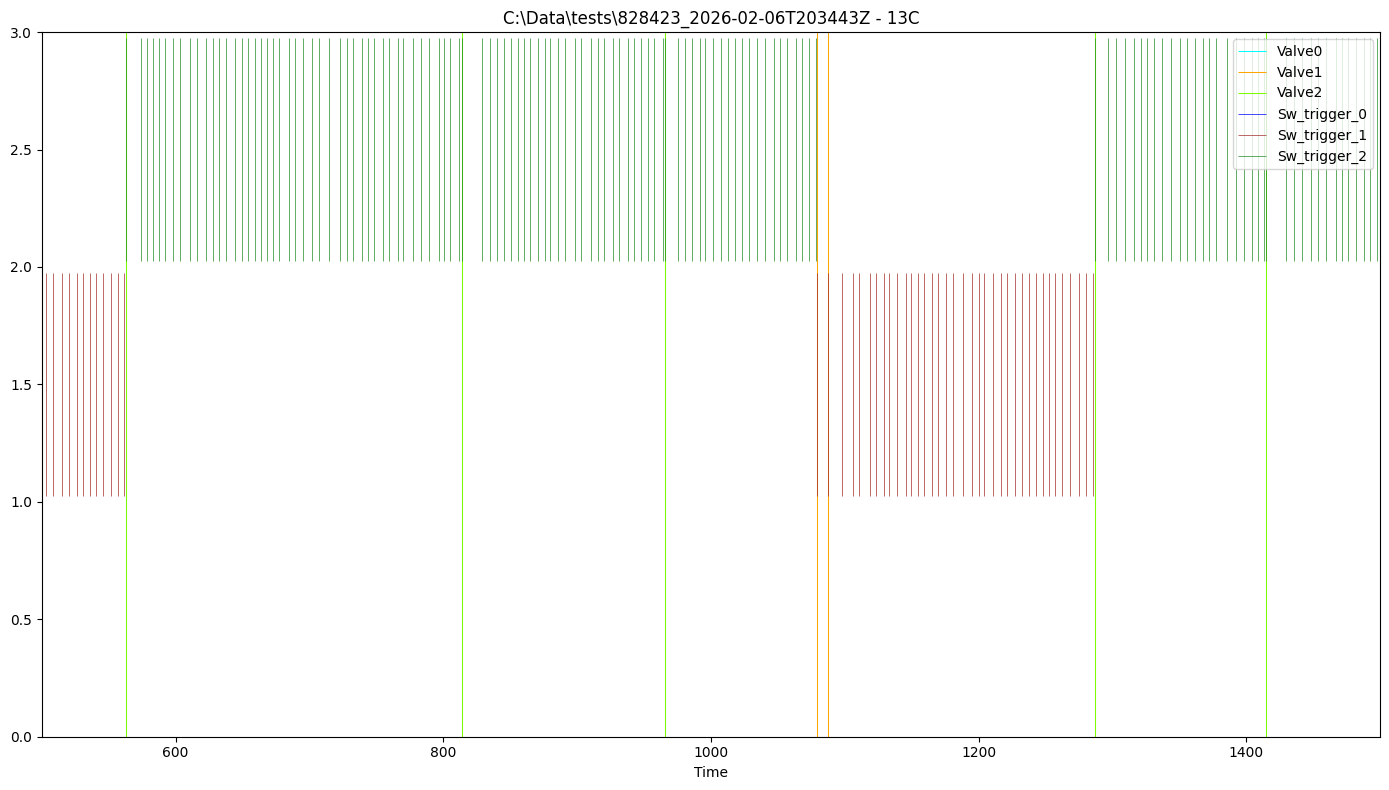

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0           4.0      4.0         1.0    0.018632   0.007227   0.027872
1           9.0      9.0         1.0    0.032007   0.010572   0.045888
2           9.0      9.0         1.0    0.029330   0.011701   0.046880
Loaded rig info: Computer - DT300539, Rig - 12C


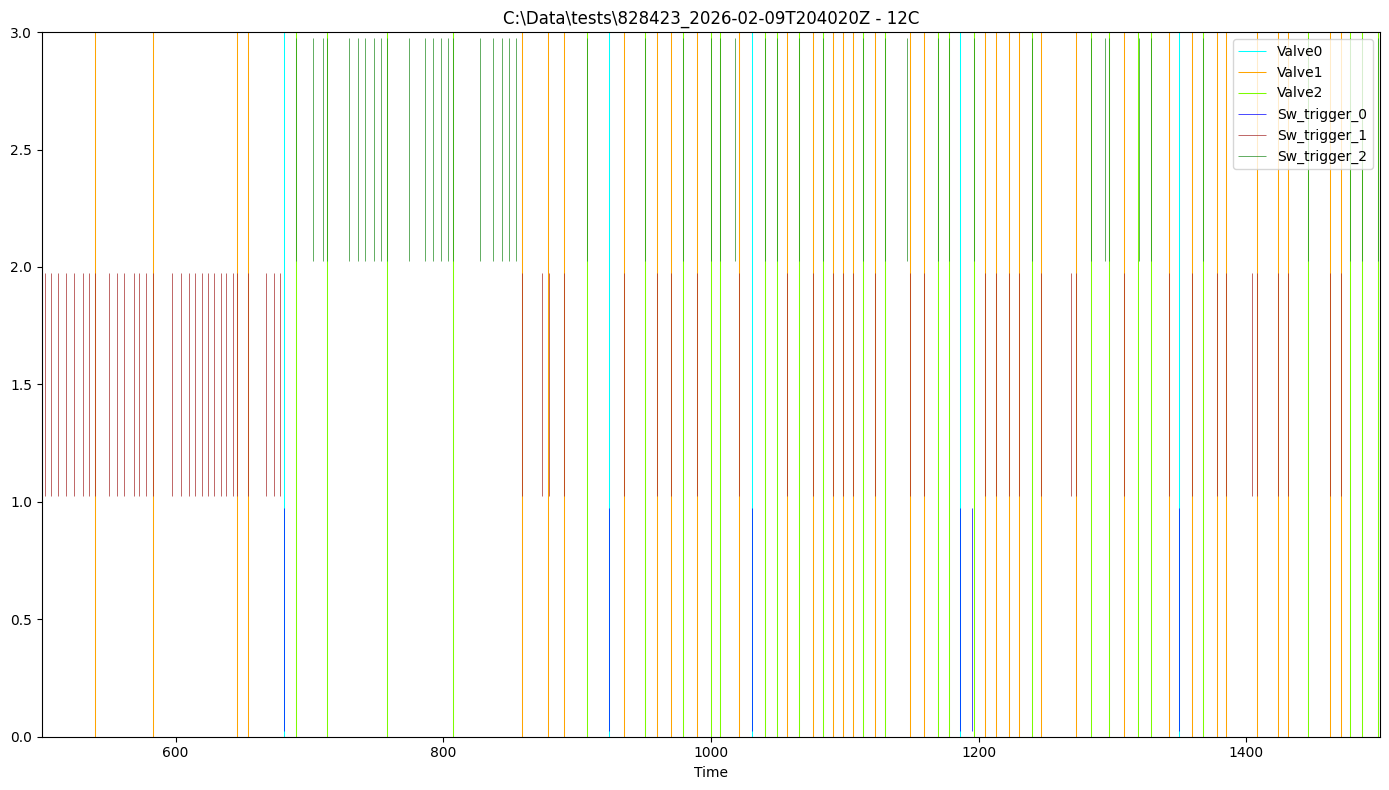

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0          19.0     19.0         1.0    0.019665   0.013471   0.062144
1         120.0    120.0         1.0    0.019008   0.010648   0.055136
2          88.0     88.0         1.0    0.023925   0.014777   0.076160
Loaded rig info: Computer - DT300562, Rig - 13B


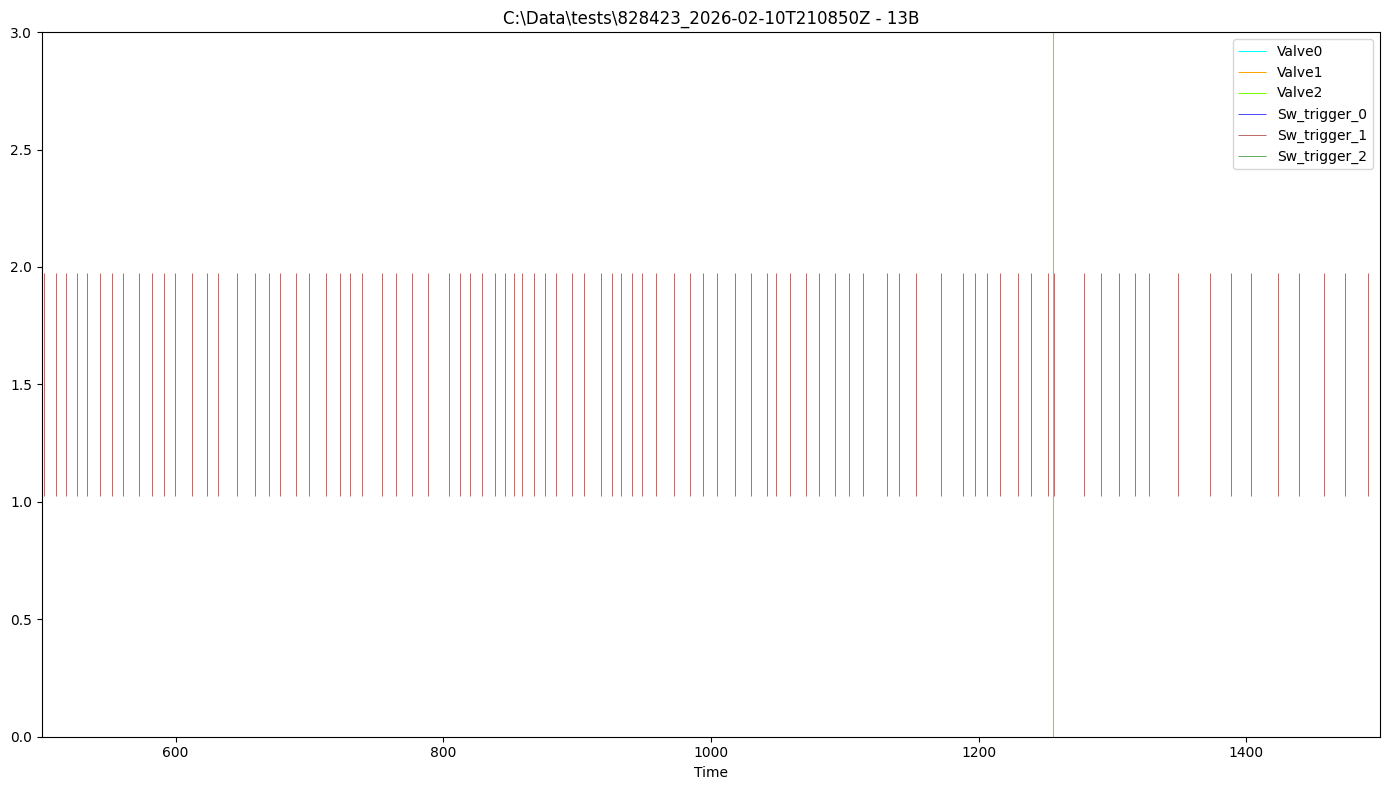

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
1           4.0      4.0         1.0    0.023344   0.014198   0.044320
2           2.0      2.0         1.0    0.042832   0.012015   0.051328
Loaded rig info: Computer - DT300043, Rig - 13A


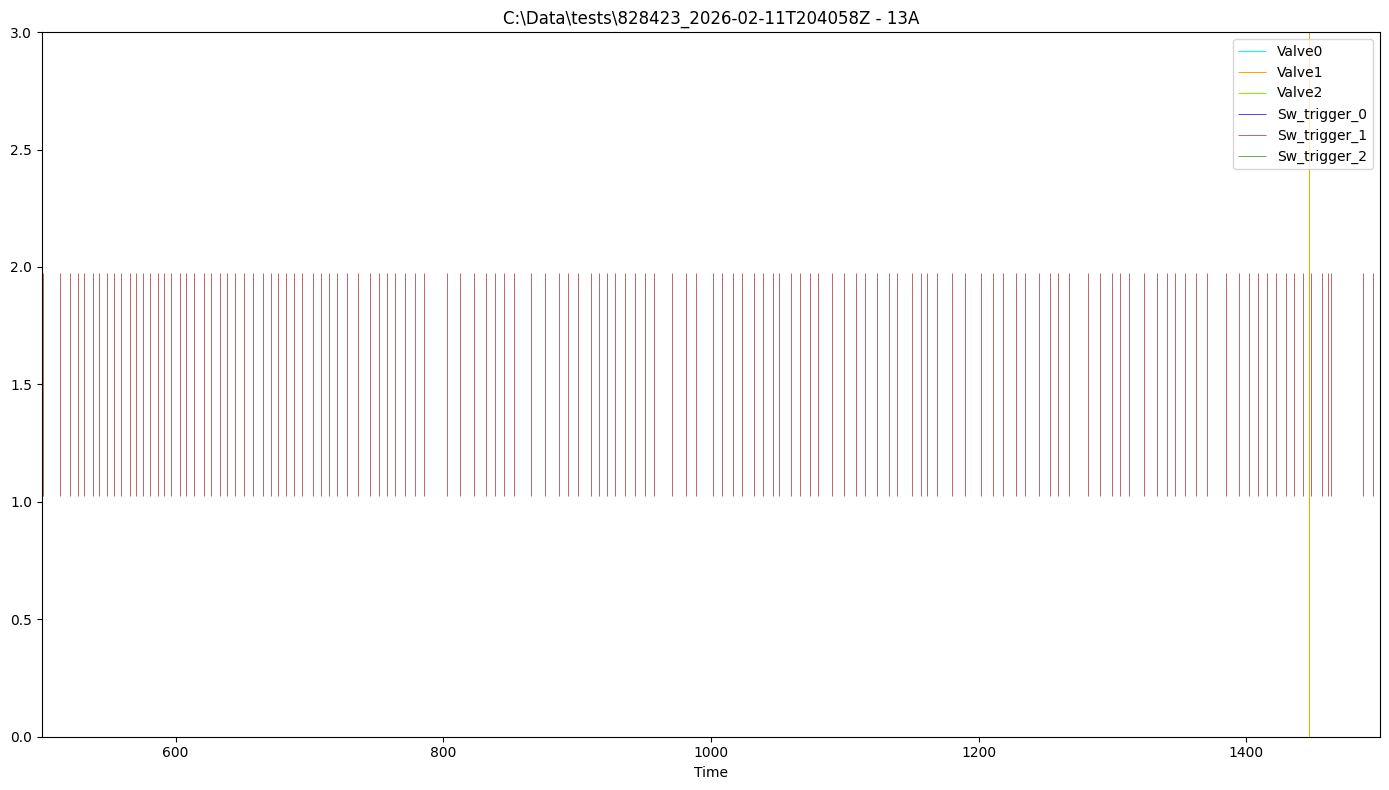

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
1          11.0      0.0         0.0    7.774551   7.225990  16.586816
2          10.0      0.0         0.0    7.533165   7.777122  16.615840
Loaded rig info: Computer - YACUMAMA, Rig - 4C


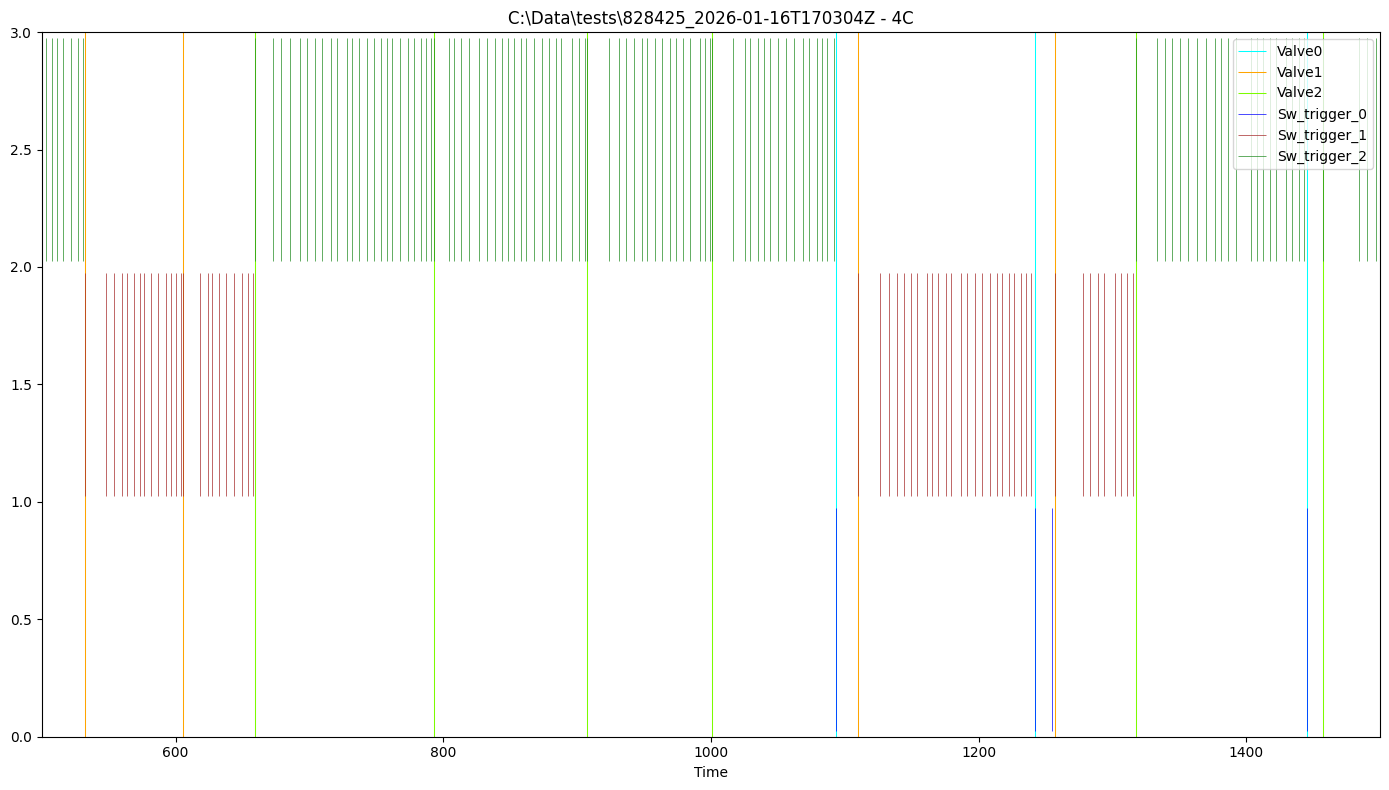

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0          10.0     10.0         1.0    0.022528   0.013625   0.056128
1          63.0     63.0         1.0    0.020655   0.015061   0.083136
2          67.0     67.0         1.0    0.022611   0.012557   0.060128
Loaded rig info: Computer - DT300043, Rig - 13A


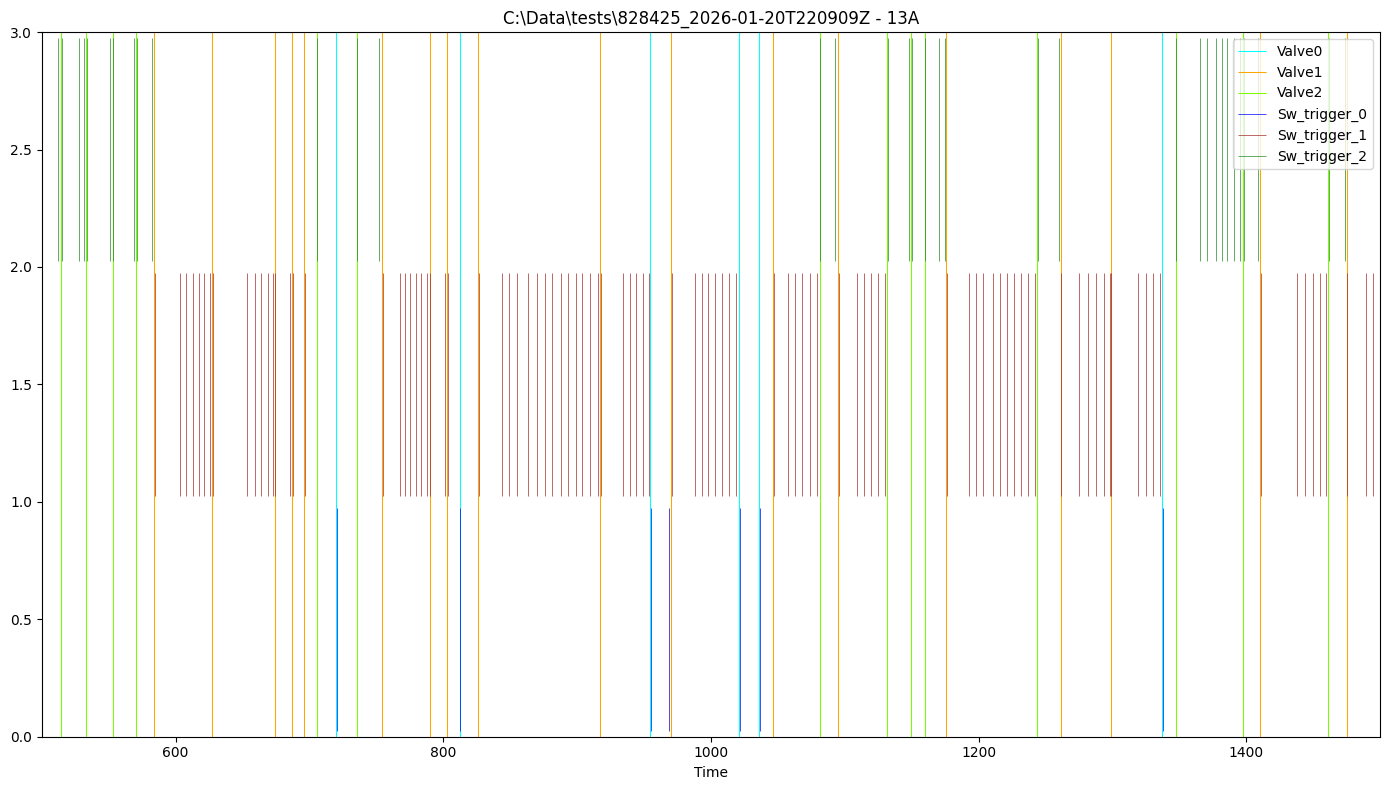

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0          16.0      0.0         0.0    0.500984   0.017389   0.523296
1          45.0      0.0         0.0    0.497478   0.019987   0.544320
2          44.0      0.0         0.0    0.498483   0.016517   0.532288
Loaded rig info: Computer - DT300043, Rig - 13A


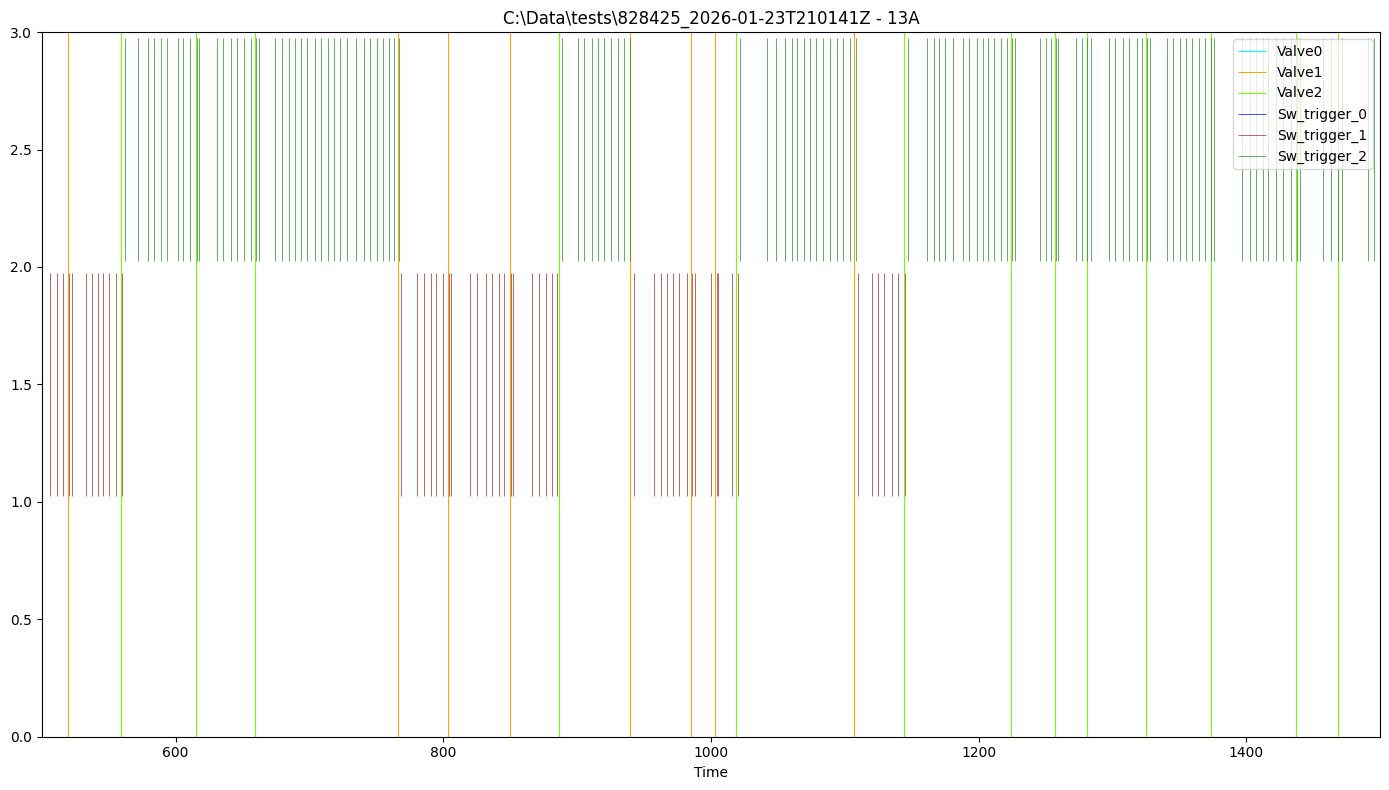

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0          12.0      0.0    0.000000    2.653117   0.021912   2.696704
1          76.0      3.0    0.039474    2.248118   0.823172   2.720704
2          87.0      3.0    0.034483    2.211270   0.867979   2.697696
Loaded rig info: Computer - DT300562, Rig - 13B


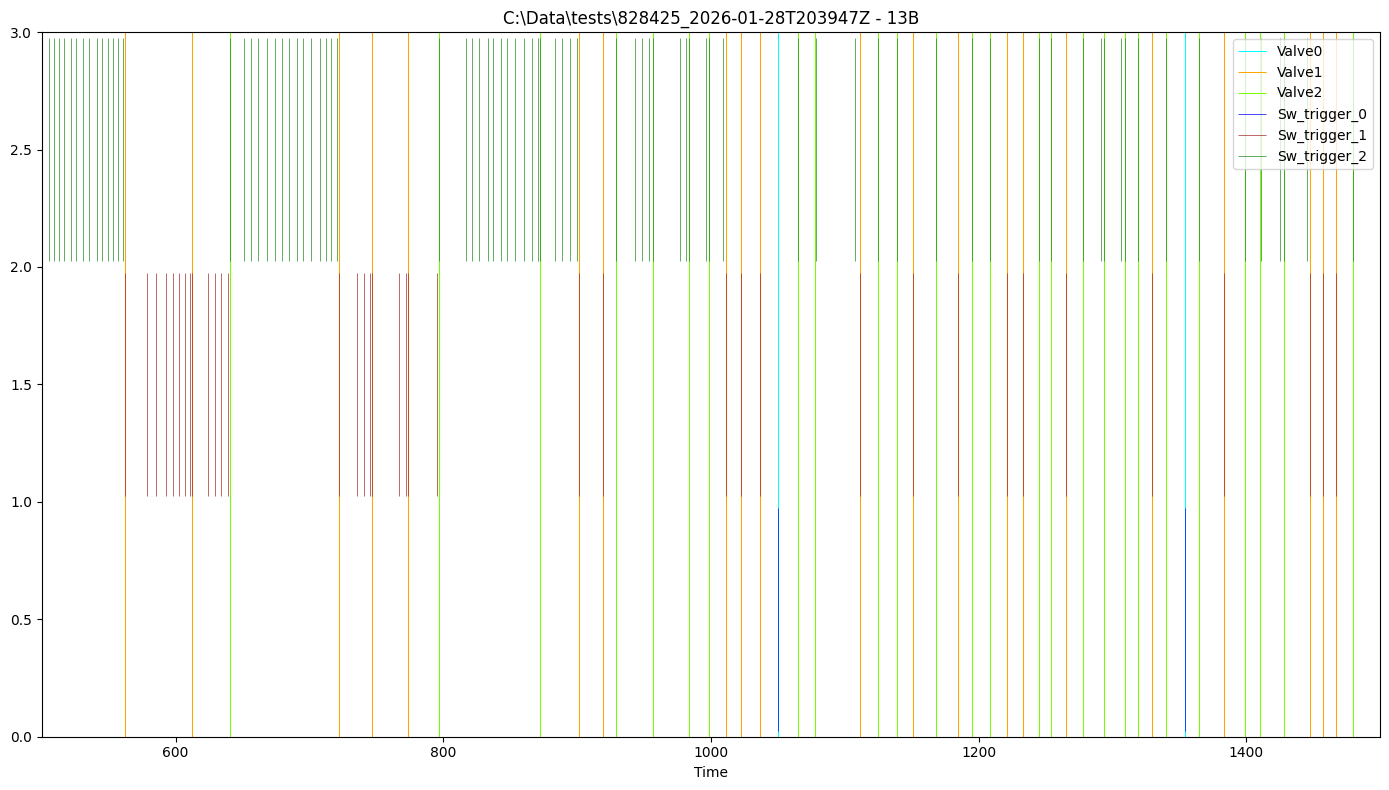

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0          18.0     18.0         1.0    0.018037   0.011212   0.048096
1         103.0    103.0         1.0    0.019841   0.012556   0.064096
2          99.0     99.0         1.0    0.021411   0.015802   0.081184
Loaded rig info: Computer - DT700150, Rig - 13C


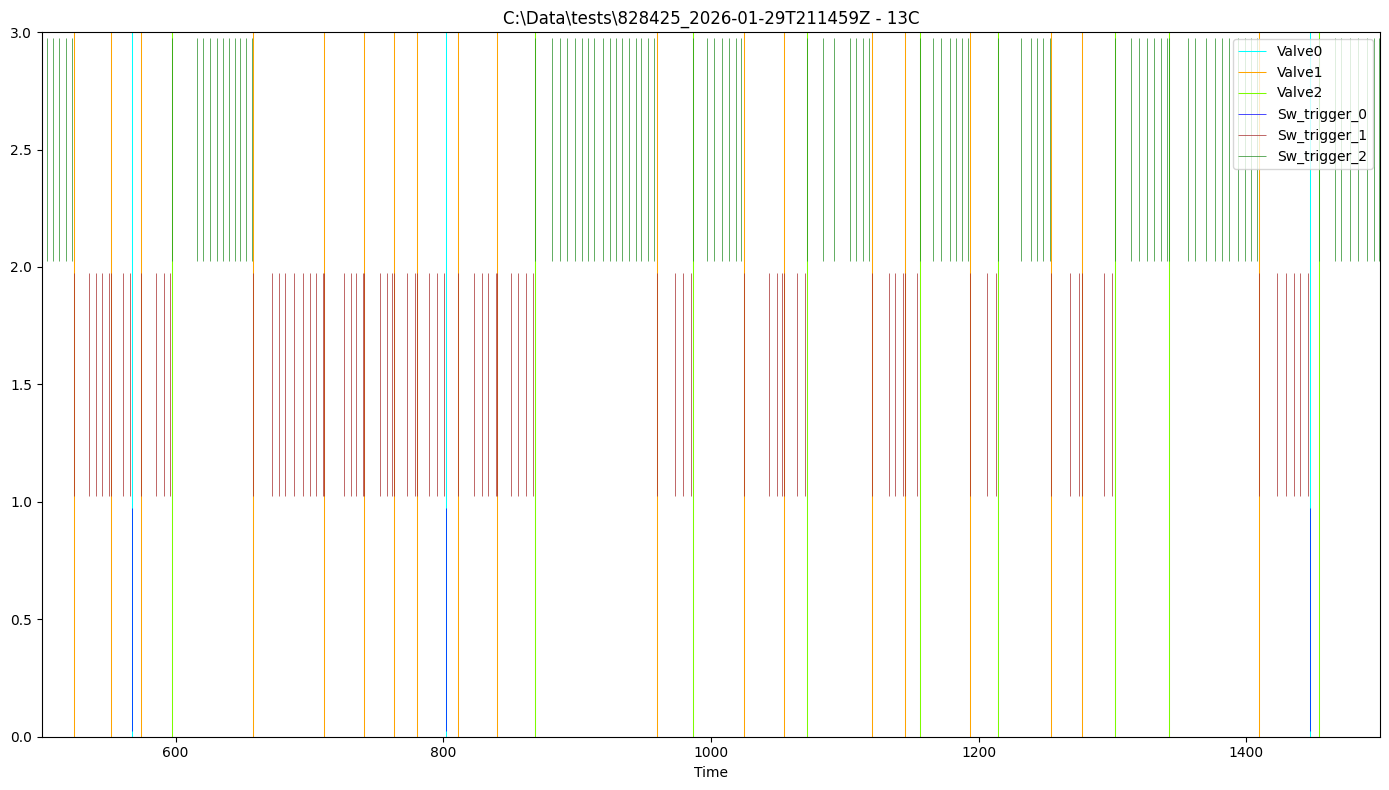

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0          16.0     16.0         1.0    0.020376   0.010444   0.043520
1          85.0     85.0         1.0    0.021241   0.015125   0.085504
2          85.0     85.0         1.0    0.020219   0.010248   0.060480
Loaded rig info: Computer - DT300562, Rig - 13B


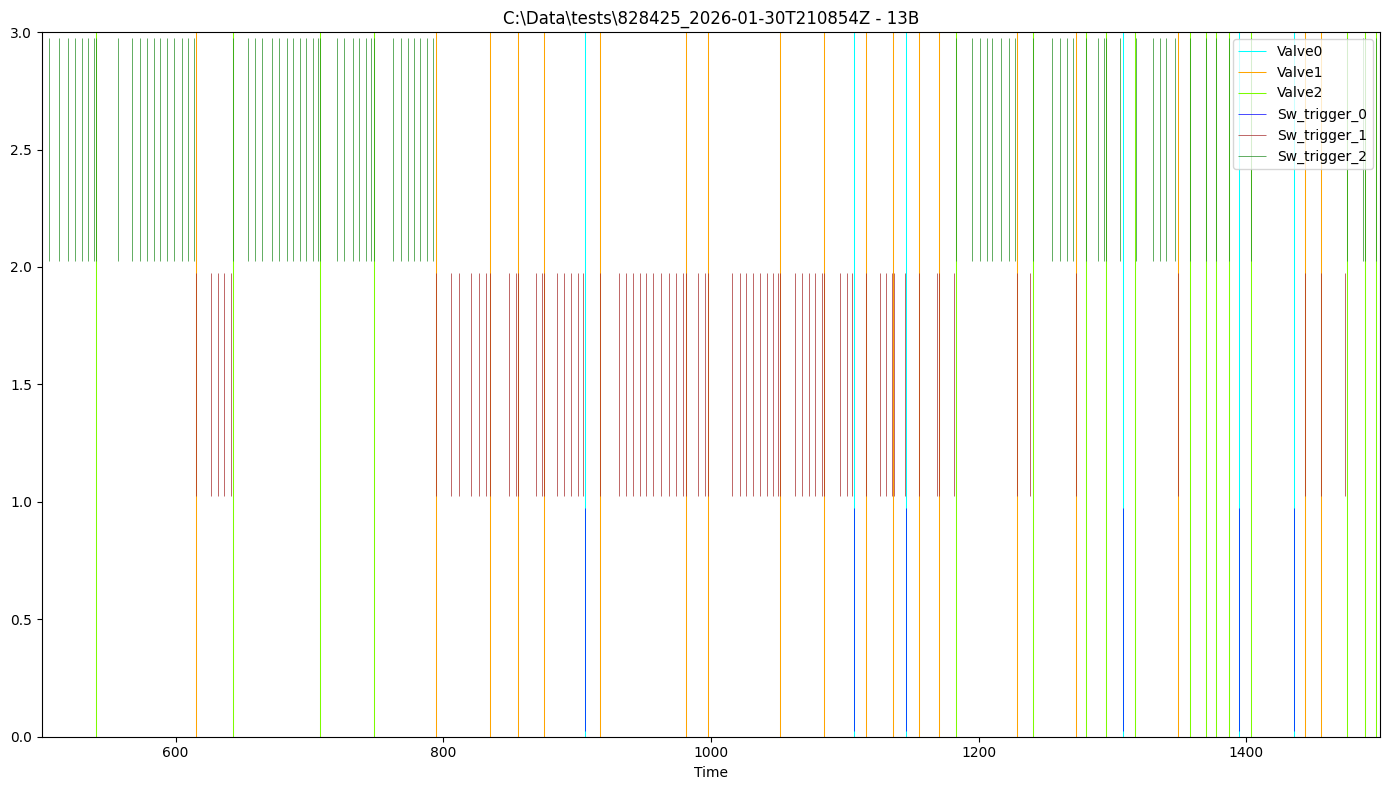

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0          31.0     31.0         1.0    0.022237   0.013388   0.051904
1         121.0    121.0         1.0    0.022593   0.013838   0.071936
2         112.0    112.0         1.0    0.022149   0.014033   0.064896
Loaded rig info: Computer - DT300539, Rig - 12C


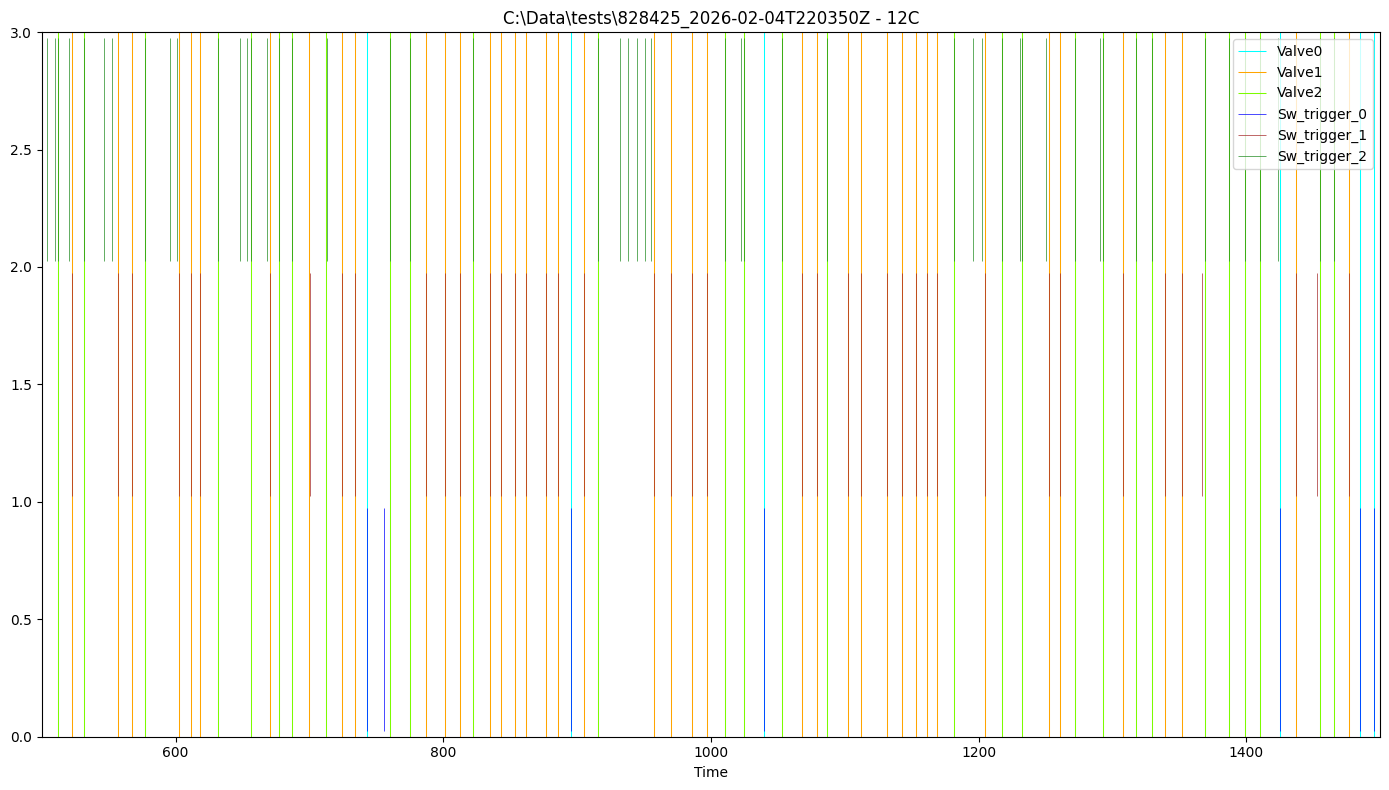

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0          22.0     22.0         1.0    0.020022   0.011936   0.045792
1         153.0    153.0         1.0    0.021104   0.012258   0.078784
2         121.0    121.0         1.0    0.021060   0.012975   0.071776
Loaded rig info: Computer - DT700150, Rig - 13C


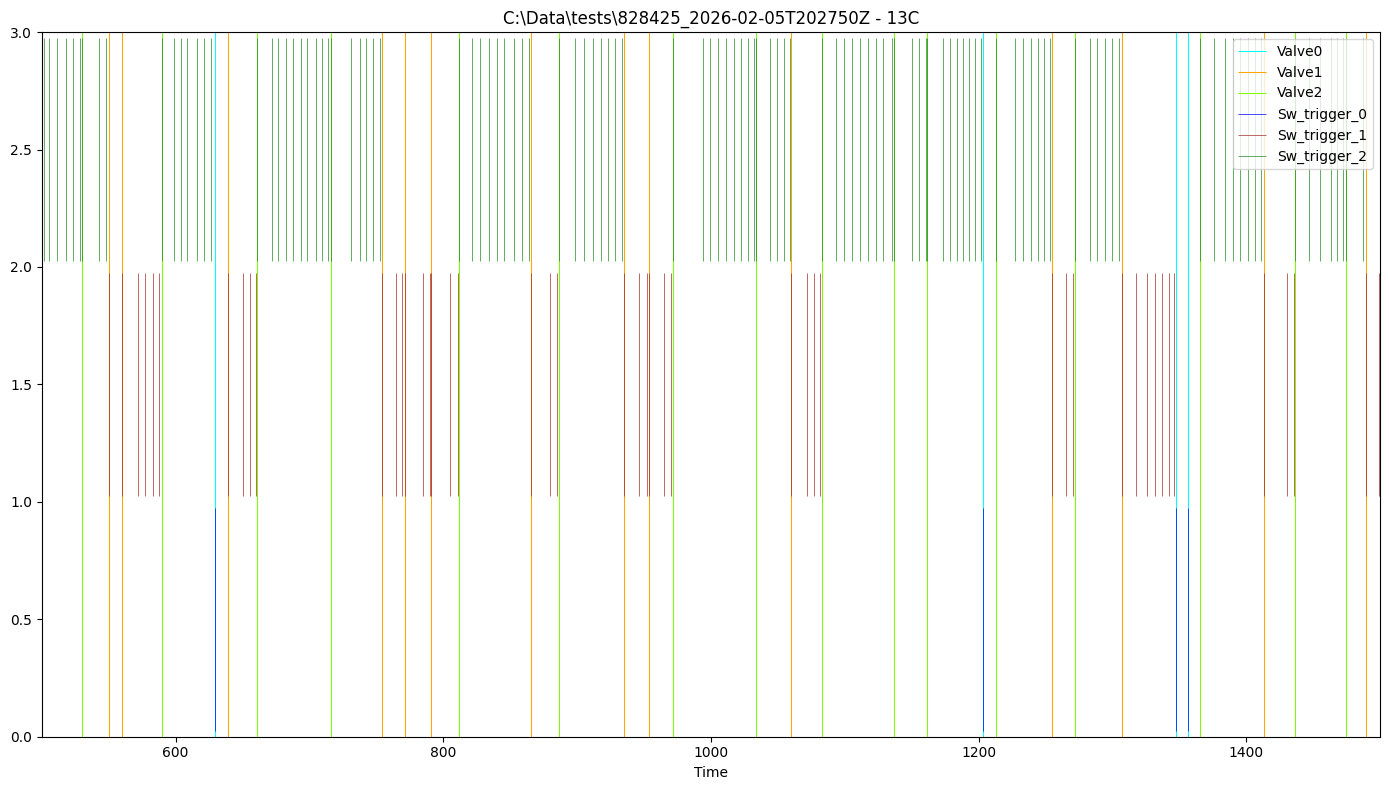

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0          19.0     19.0         1.0    0.026605   0.014486   0.053568
1          67.0     67.0         1.0    0.024237   0.013516   0.059552
2          77.0     77.0         1.0    0.026553   0.014402   0.060608
Loaded rig info: Computer - ABAIA, Rig - 4D


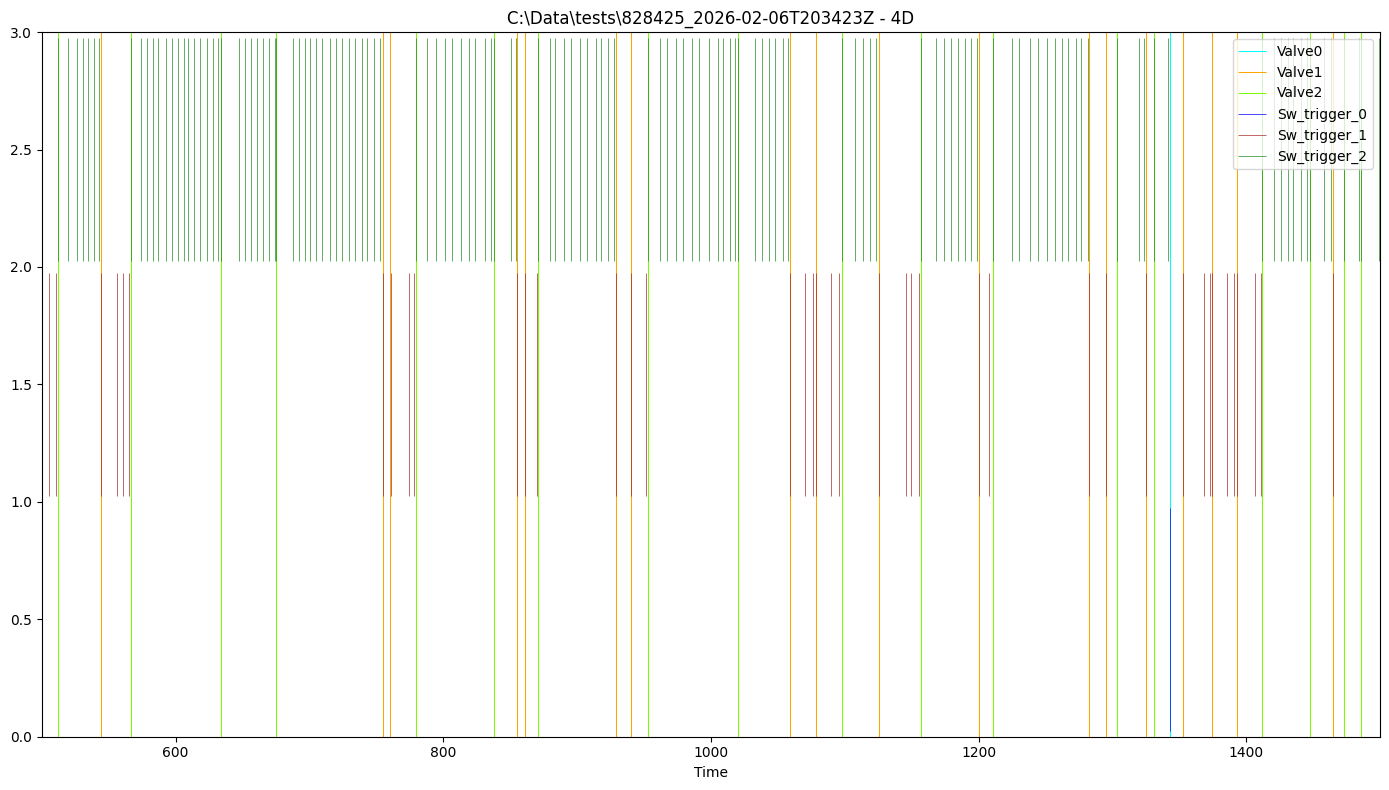

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0          18.0     18.0         1.0    0.022930   0.013163   0.050144
1         106.0    106.0         1.0    0.020298   0.010844   0.049152
2          87.0     87.0         1.0    0.020827   0.012281   0.055168
Loaded rig info: Computer - DT300562, Rig - 13B


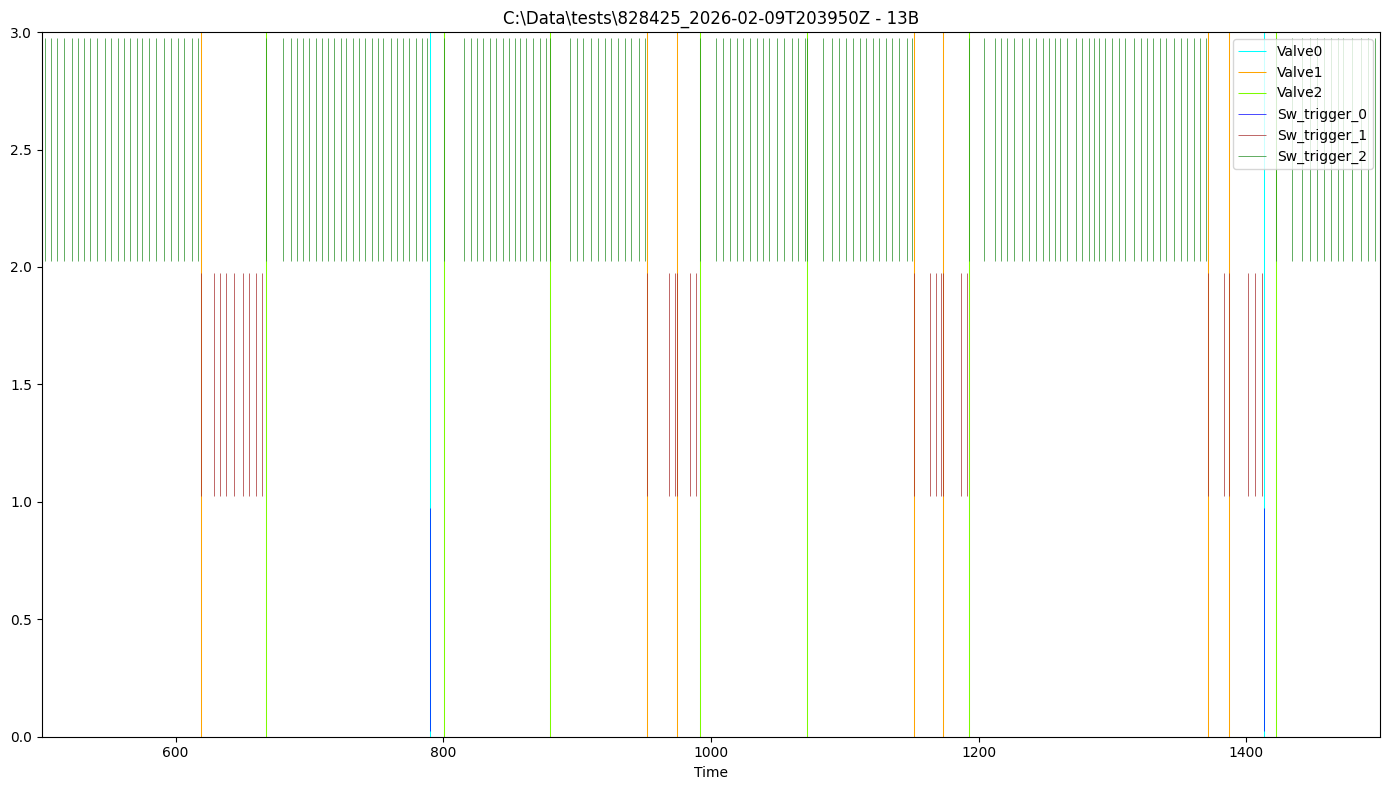

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0           6.0      6.0         1.0    0.024613   0.016882   0.046016
1          46.0     46.0         1.0    0.021826   0.012043   0.052928
2          42.0     42.0         1.0    0.023126   0.014964   0.062944
Loaded rig info: Computer - DT300539, Rig - 12C


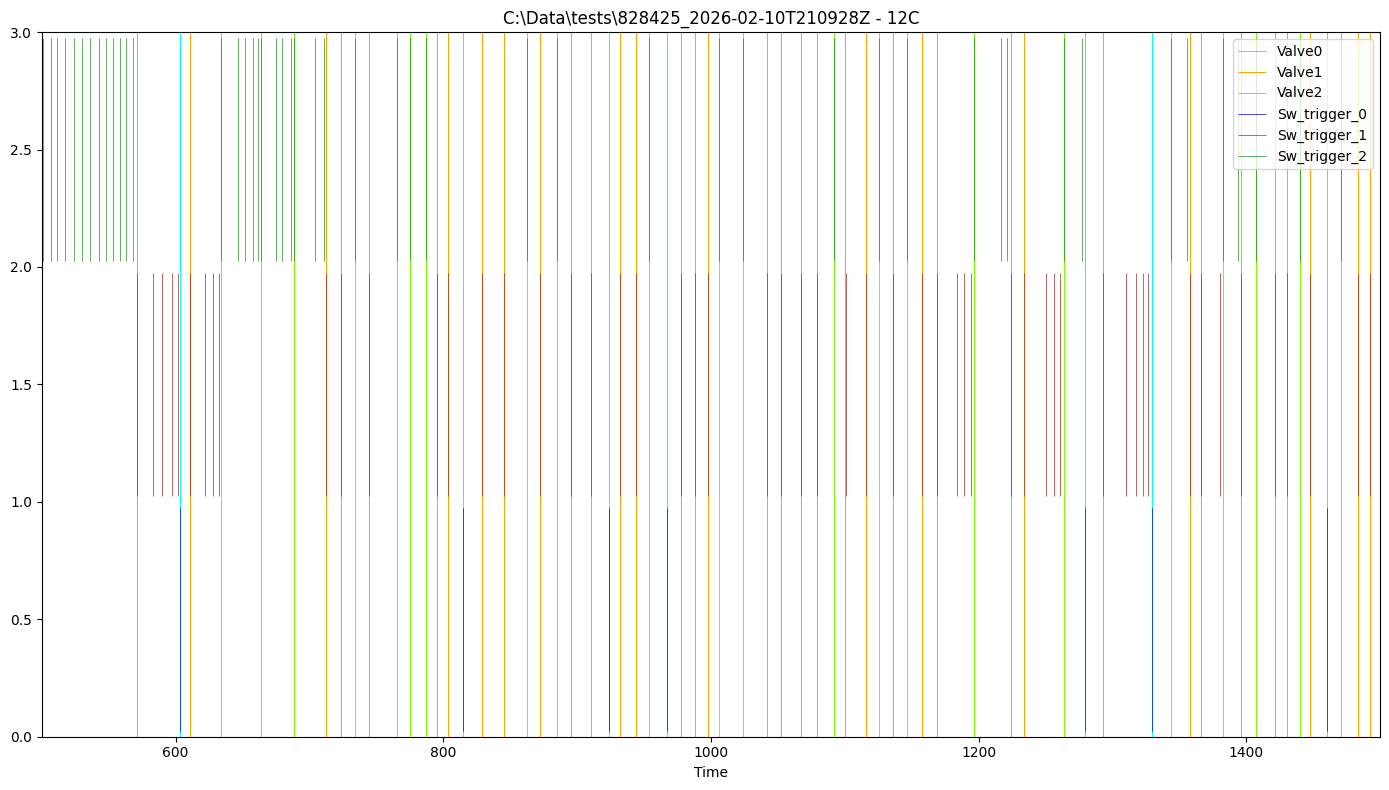

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0          30.0     30.0         1.0    0.020847   0.009840   0.043520
1          98.0     98.0         1.0    0.020502   0.011420   0.055520
2          87.0     87.0         1.0    0.019817   0.011622   0.056512
Loaded rig info: Computer - DT700150, Rig - 13C


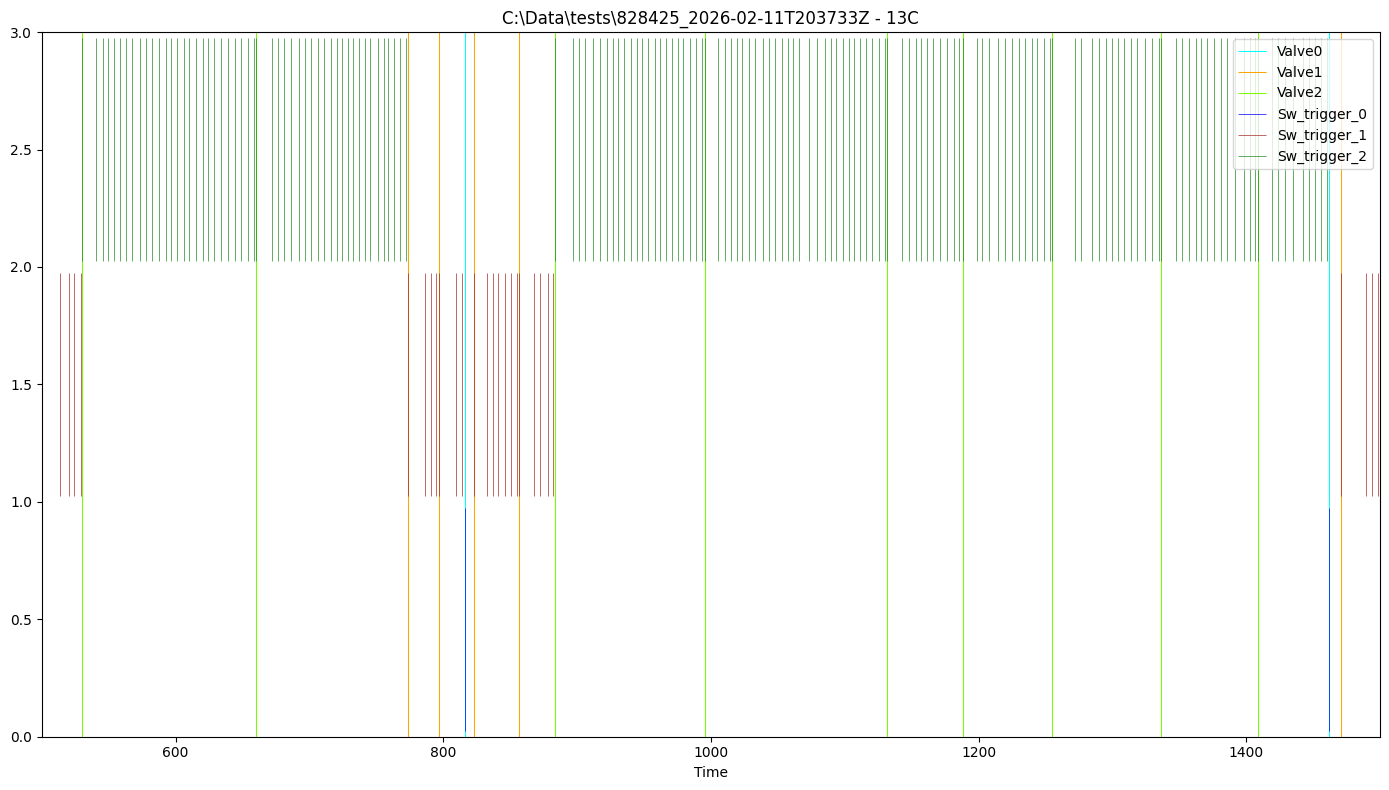

         events  matched  match_rate  mean_delta  std_delta  max_delta
channel                                                               
0          13.0     13.0         1.0    0.019897   0.012439   0.052928
1          70.0     70.0         1.0    0.018826   0.010726   0.054880
2          52.0     52.0         1.0    0.018491   0.011925   0.064896


In [ ]:
# Analysis of all tests inside a given directory

main_path = Path(r"C:\Data\tests")

for session_dir in main_path.iterdir():
    rig = get_rig_n(str(session_dir))
    run_analysis_in_single_folder(str(session_dir), rig_n=rig, xlim=(500,1500))

  